# NB08 — Method C: Clustering-based Pseudo-labeling

CN7/RG3 + 동일 장비로 필터링한 unlabeled 71,180행에 이상탐지 기법 9종을 적용해 ROC-AUC로 비교하고, 최적 기법으로 pseudo-label을 생성한 뒤 준지도 학습 성능 향상을 검증한다.

| 단계 | 내용 |
|---|---|
| 1 | EQUIP/PART 필터링 + PCA/UMAP 시각화 |
| 2 | IF·LOF·HBOS·COPOD·GMM·K-Means·OC-SVM·EE·KNN 전체 비교 (ROC-AUC) |
| 3 | 최적 기법으로 pseudo-label 생성 + labeled 검증 |
| 4 | QDA/RF/MLP: labeled only vs labeled+pseudo-defects 비교 |
| 5 | Ablation (contamination threshold × pseudo-label source) |

## 0. 환경 설정

In [ ]:
%matplotlib inline

In [ ]:
%matplotlib inline

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
from time import time
import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.mixture import GaussianMixture
from sklearn.svm import OneClassSVM
from sklearn.cluster import MiniBatchKMeans
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

try:
    from pyod.models.hbos import HBOS
    from pyod.models.copod import COPOD
    from pyod.models.knn import KNN as PyODKNN
    HAS_PYOD = True
    print("pyod: OK")
except ImportError:
    HAS_PYOD = False
    print("pyod not available")

try:
    import umap as umap_lib
    HAS_UMAP = True
    print("umap: OK")
except ImportError:
    HAS_UMAP = False
    print("umap not available — pip install umap-learn")

SEED = 42
np.random.seed(SEED)
BASE = Path(r'E:\IAAI_Term_project')
FIG_DIR = BASE / 'results/figures'
TAB_DIR = BASE / 'results/tables'
SPLIT_DIR = BASE / 'data/splits'
FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR.mkdir(exist_ok=True, parents=True)

def setup_korean_font():
    import matplotlib.font_manager as fm
    for f in fm.fontManager.ttflist:
        if 'Malgun' in f.name:
            plt.rcParams['font.family'] = f.name
            break
    plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid')
setup_korean_font()
print("Setup complete. SEED =", SEED)

pyod: OK


umap: OK
Setup complete. SEED = 42


## 1. 데이터 로드 및 CN7/RG3 필터링

In [3]:
print("Loading labeled data...")
lab = pd.read_csv(BASE / 'data/raw/labeled_data.csv')
lab['label'] = (lab['PassOrFail'] == 'N').astype(int)

print("Loading unlabeled data (795K)...")
unlab = pd.read_csv(BASE / 'data/raw/unlabeled_data.csv')

# Filter: CN7/RG3 products + same machines as labeled
eq_vals = set(lab['EQUIP_NAME'].unique())
cn7rg3 = [p for p in lab['PART_NAME'].unique() if 'CN7' in p or 'RG3' in p]
mask_filt = unlab['EQUIP_NAME'].isin(eq_vals) & unlab['PART_NAME'].isin(cn7rg3)
unlab_filt = unlab[mask_filt].reset_index(drop=True)

print(f"\nLabeled : {len(lab):,} rows | 불량 {lab['label'].sum()} ({lab['label'].mean()*100:.2f}%)")
print(f"Unlabeled (all)  : {len(unlab):,} rows")
print(f"Unlabeled (CN7/RG3+기계 필터) : {len(unlab_filt):,} rows ({len(unlab_filt)/len(unlab)*100:.1f}%)")
print(f"\nEquip filter : {list(eq_vals)}")
print(f"Part  filter : {cn7rg3}")

DEFECT_RATE = lab['label'].mean()
print(f"\nLabeled 불량률: {DEFECT_RATE*100:.4f}% → contamination 기준으로 사용")

Loading labeled data...
Loading unlabeled data (795K)...



Labeled : 7,996 rows | 불량 71 (0.89%)
Unlabeled (all)  : 795,315 rows
Unlabeled (CN7/RG3+기계 필터) : 71,180 rows (8.9%)

Equip filter : ['650톤-우진', '1800TON-우진', '650톤-우진2호기']
Part  filter : ["CN7 W/S SIDE MLD'G RH", "CN7 W/S SIDE MLD'G LH", "RG3 MOLD'G W/SHLD, LH", "RG3 MOLD'G W/SHLD, RH"]

Labeled 불량률: 0.8879% → contamination 기준으로 사용


## 2. 피처 준비 — 25개 유효 피처 + StandardScaler

In [4]:
ZERO_VAR = [
    'Mold_Temperature_1','Mold_Temperature_2','Mold_Temperature_5',
    'Mold_Temperature_6','Mold_Temperature_7','Mold_Temperature_8',
    'Mold_Temperature_9','Mold_Temperature_10','Mold_Temperature_11',
    'Mold_Temperature_12','Barrel_Temperature_7'
]
META = {'_id','Unnamed: 0','TimeStamp','PART_FACT_PLAN_DATE','PART_FACT_SERIAL',
        'PART_NAME','EQUIP_CD','EQUIP_NAME','PassOrFail','Reason','ERR_FACT_QTY','label'}

feature_cols = [c for c in lab.columns
                if c not in META and c not in ZERO_VAR
                and lab[c].dtype in ['float64','int64','float32','int32']]
print(f"피처 수: {len(feature_cols)}")
print(feature_cols)

X_lab = lab[feature_cols].values.astype(float)
y_lab = lab['label'].values
mask_normal  = y_lab == 0
mask_defect  = y_lab == 1

feat_unlab = [c for c in feature_cols if c in unlab_filt.columns]
X_unlab = unlab_filt[feat_unlab].fillna(0).values.astype(float)

# Scaler fit on filtered unlabeled (unsupervised — no label info used)
scaler_unlab = StandardScaler()
X_unlab_sc = scaler_unlab.fit_transform(X_unlab)
X_lab_sc    = scaler_unlab.transform(X_lab)

print(f"\nX_lab : {X_lab.shape}  |  불량 {mask_defect.sum()}, 양품 {mask_normal.sum()}")
print(f"X_unlab: {X_unlab.shape}")

피처 수: 25
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

X_lab : (7996, 25)  |  불량 71, 양품 7925
X_unlab: (71180, 25)


## 3. PCA 시각화 — Unlabeled 배경 + Labeled 전경

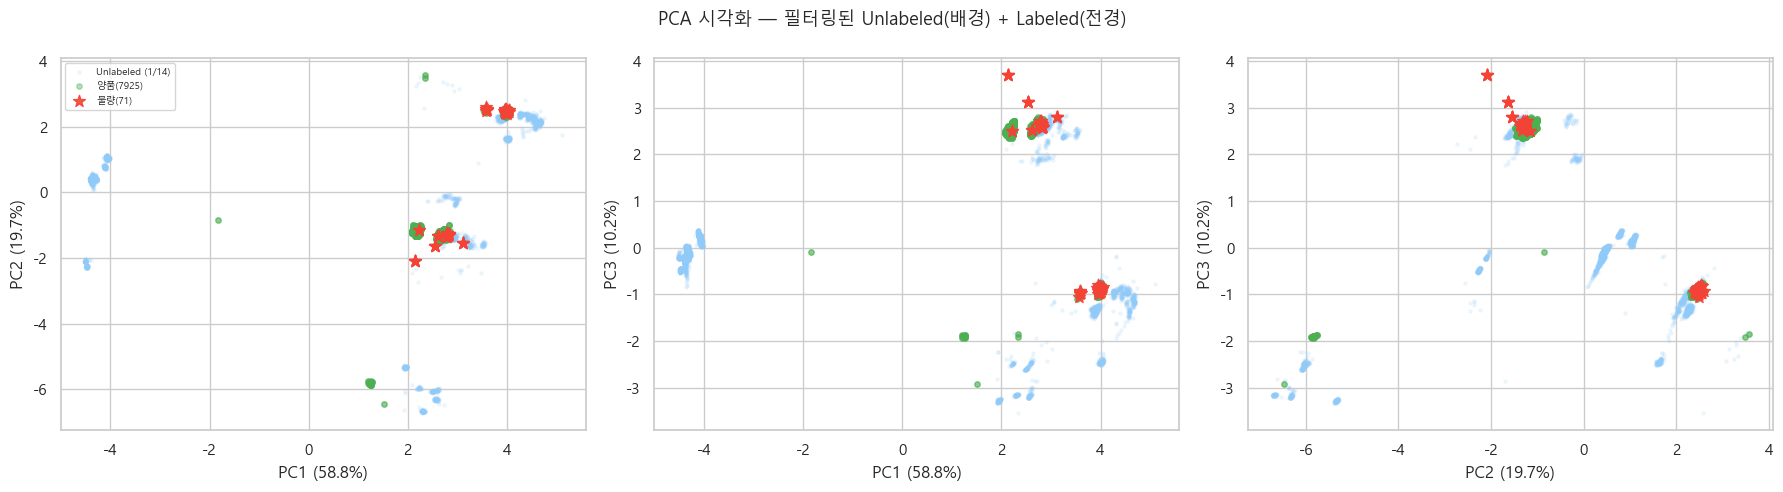

Saved: E:\IAAI_Term_project\results\figures\NB08_fig1_pca_visualization.png
누적 설명분산: PC3까지 88.8%


In [5]:
pca = PCA(n_components=3, random_state=SEED)
pca.fit(X_unlab_sc)
X_unlab_pca = pca.transform(X_unlab_sc)
X_lab_pca   = pca.transform(X_lab_sc)
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA 시각화 — 필터링된 Unlabeled(배경) + Labeled(전경)', fontsize=13)

pairs = [(0,1),(0,2),(1,2)]
for ax, (i, j) in zip(axes, pairs):
    step = max(1, len(X_unlab_pca) // 5000)
    ax.scatter(X_unlab_pca[::step, i], X_unlab_pca[::step, j],
               alpha=0.12, s=5, c='#90CAF9', label=f'Unlabeled (1/{step})')
    ax.scatter(X_lab_pca[mask_normal, i], X_lab_pca[mask_normal, j],
               alpha=0.4, s=15, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
    ax.scatter(X_lab_pca[mask_defect, i], X_lab_pca[mask_defect, j],
               alpha=0.9, s=80, c='#F44336', marker='*',
               label=f'불량({mask_defect.sum()})', zorder=4)
    ax.set_xlabel(f'PC{i+1} ({evr[i]*100:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({evr[j]*100:.1f}%)')
    if i==0 and j==1: ax.legend(fontsize=7)

plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig1_pca_visualization.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
print(f"누적 설명분산: PC3까지 {evr[:3].sum()*100:.1f}%")

In [ ]:
# ── [Step 1] PCA 3D 시각화 ──────────────────────────────────────────────────
print("PCA 3D 시각화...")
fig = plt.figure(figsize=(14, 10))
ax3 = fig.add_subplot(111, projection='3d')
s3 = max(1, len(X_unlab_pca)//3000)
ax3.scatter(X_unlab_pca[::s3,0], X_unlab_pca[::s3,1], X_unlab_pca[::s3,2],
            alpha=0.07, s=5, c='#90CAF9', label=f'Unlabeled(1/{s3})')
ax3.scatter(X_lab_pca[mask_normal,0], X_lab_pca[mask_normal,1], X_lab_pca[mask_normal,2],
            alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
ax3.scatter(X_lab_pca[mask_defect,0], X_lab_pca[mask_defect,1], X_lab_pca[mask_defect,2],
            alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
ax3.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)'); ax3.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax3.set_zlabel(f'PC3 ({evr[2]*100:.1f}%)')
ax3.set_title('PCA 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/'NB08_fig1b_pca3d.png', dpi=150, bbox_inches='tight')
plt.show(); print("PCA 3D 저장 완료")
print("불량 3D 범위:")
for nm, col in [('PC1',0),('PC2',1),('PC3',2)]:
    d_mn = X_lab_pca[mask_defect,col].min(); d_mx = X_lab_pca[mask_defect,col].max()
    n_mn = X_lab_pca[mask_normal,col].min(); n_mx = X_lab_pca[mask_normal,col].max()
    print(f"  {nm}: 불량[{d_mn:.2f},{d_mx:.2f}]  양품[{n_mn:.2f},{n_mx:.2f}]")

In [ ]:
# ── [Step 1] PCA 3D 시각화 ──────────────────────────────────────────────────
print("PCA 3D 시각화...")
fig = plt.figure(figsize=(14, 10))
ax3 = fig.add_subplot(111, projection='3d')
s3 = max(1, len(X_unlab_pca)//3000)
ax3.scatter(X_unlab_pca[::s3,0], X_unlab_pca[::s3,1], X_unlab_pca[::s3,2],
            alpha=0.07, s=5, c='#90CAF9', label=f'Unlabeled(1/{s3})')
ax3.scatter(X_lab_pca[mask_normal,0], X_lab_pca[mask_normal,1], X_lab_pca[mask_normal,2],
            alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
ax3.scatter(X_lab_pca[mask_defect,0], X_lab_pca[mask_defect,1], X_lab_pca[mask_defect,2],
            alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
ax3.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)'); ax3.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax3.set_zlabel(f'PC3 ({evr[2]*100:.1f}%)')
ax3.set_title('PCA 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/'NB08_fig1b_pca3d.png', dpi=150, bbox_inches='tight')
plt.show(); print("PCA 3D 저장 완료")
print("불량 3D 범위:")
for nm, col in [('PC1',0),('PC2',1),('PC3',2)]:
    d_mn = X_lab_pca[mask_defect,col].min(); d_mx = X_lab_pca[mask_defect,col].max()
    n_mn = X_lab_pca[mask_normal,col].min(); n_mx = X_lab_pca[mask_normal,col].max()
    print(f"  {nm}: 불량[{d_mn:.2f},{d_mx:.2f}]  양품[{n_mn:.2f},{n_mx:.2f}]")

PCA 3D 시각화...


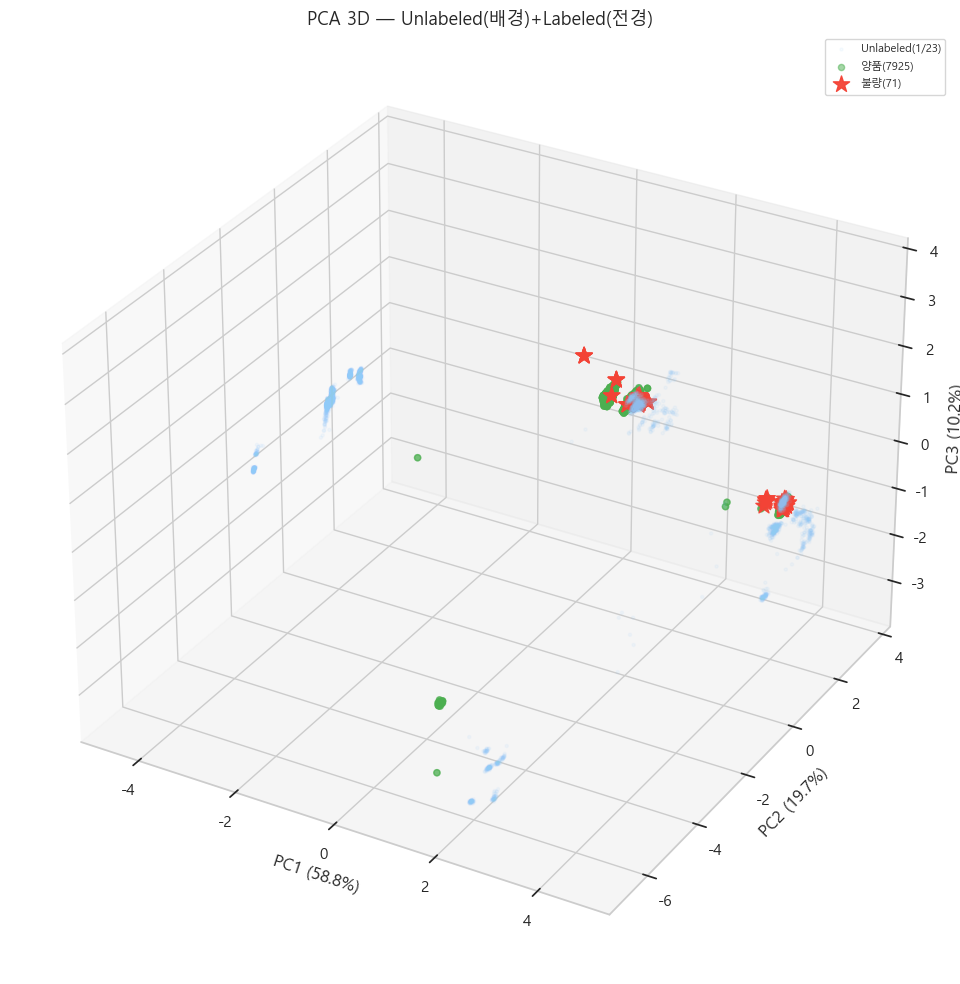

PCA 3D 저장 완료
불량 3D 범위:
  PC1: 불량[2.14,4.04]  양품[-1.83,4.06]
  PC2: 불량[-2.09,2.59]  양품[-6.47,3.57]
  PC3: 불량[-1.05,3.69]  양품[-2.92,2.80]


In [6]:
# ── [Step 1] PCA 3D 시각화 ──────────────────────────────────────────────────
print("PCA 3D 시각화...")
fig = plt.figure(figsize=(14, 10))
ax3 = fig.add_subplot(111, projection='3d')
s3 = max(1, len(X_unlab_pca)//3000)
ax3.scatter(X_unlab_pca[::s3,0], X_unlab_pca[::s3,1], X_unlab_pca[::s3,2],
            alpha=0.07, s=5, c='#90CAF9', label=f'Unlabeled(1/{s3})')
ax3.scatter(X_lab_pca[mask_normal,0], X_lab_pca[mask_normal,1], X_lab_pca[mask_normal,2],
            alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
ax3.scatter(X_lab_pca[mask_defect,0], X_lab_pca[mask_defect,1], X_lab_pca[mask_defect,2],
            alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
ax3.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)'); ax3.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax3.set_zlabel(f'PC3 ({evr[2]*100:.1f}%)')
ax3.set_title('PCA 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/'NB08_fig1b_pca3d.png', dpi=150, bbox_inches='tight')
plt.show(); print("PCA 3D 저장 완료")
print("불량 3D 범위:")
for nm, col in [('PC1',0),('PC2',1),('PC3',2)]:
    d_mn = X_lab_pca[mask_defect,col].min(); d_mx = X_lab_pca[mask_defect,col].max()
    n_mn = X_lab_pca[mask_normal,col].min(); n_mx = X_lab_pca[mask_normal,col].max()
    print(f"  {nm}: 불량[{d_mn:.2f},{d_mx:.2f}]  양품[{n_mn:.2f},{n_mx:.2f}]")

In [7]:
# ── [Step 1 PCA 해석] ──────────────────────────────────────────────────────
print("=" * 65)
print("[PCA 결과 해석]")
print("=" * 65)

print(f"\n▶ 설명 분산 (주성분별):")
for i, ev in enumerate(evr[:3]):
    bar = "█" * int(ev * 40)
    print(f"  PC{i+1}: {ev*100:5.1f}%  {bar}")
print(f"  누적(PC1~3): {evr[:3].sum()*100:.1f}%  → 상위 3개 주성분으로 대부분 분산 포착")

pc1_def  = X_lab_pca[mask_defect, 0]
pc1_norm = X_lab_pca[mask_normal, 0]
pc2_def  = X_lab_pca[mask_defect, 1]
pc2_norm = X_lab_pca[mask_normal, 1]

in_range_pc1 = np.sum((pc1_def >= pc1_norm.min()) & (pc1_def <= pc1_norm.max()))
in_range_pc2 = np.sum((pc2_def >= pc2_norm.min()) & (pc2_def <= pc2_norm.max()))

print(f"\n▶ 불량({mask_defect.sum()}개)의 양품 PC 범위 내 혼재 비율:")
print(f"  PC1: {in_range_pc1}/{mask_defect.sum()} = {in_range_pc1/mask_defect.sum()*100:.0f}%  "
      f"(양품 범위: [{pc1_norm.min():.2f}, {pc1_norm.max():.2f}])")
print(f"  PC2: {in_range_pc2}/{mask_defect.sum()} = {in_range_pc2/mask_defect.sum()*100:.0f}%  "
      f"(양품 범위: [{pc2_norm.min():.2f}, {pc2_norm.max():.2f}])")
print(f"  → 불량 대부분이 양품 PCA 공간 내에 혼재 — 선형 분리 불가")

overlap_unlab = np.sum(
    (X_unlab_pca[:, 0] >= pc1_norm.min()) & (X_unlab_pca[:, 0] <= pc1_norm.max())
)
print(f"\n▶ Unlabeled-Labeled 공간 겹침:")
print(f"  필터링 Unlabeled {len(X_unlab_pca):,}행 중 PC1 양품 범위 내: "
      f"{overlap_unlab:,}개 ({overlap_unlab/len(X_unlab_pca)*100:.1f}%)")
print(f"  → CN7/RG3+기계 필터링 후 unlabeled와 labeled가 유사한 PCA 공간에 분포 — 도메인 필터링 유효")

print(f"\n▶ 결론:")
print(f"  (1) PC3까지 {evr[:3].sum()*100:.1f}% 설명 → 25차원 데이터가 소수 방향으로 압축됨")
print(f"  (2) 불량 {in_range_pc1/mask_defect.sum()*100:.0f}%가 PC1 양품 범위 내 혼재 → 이상탐지 어려운 구조")
print(f"  (3) Unlabeled {overlap_unlab/len(X_unlab_pca)*100:.1f}%가 동일 공간 → 도메인 필터링 적절성 확인")

[PCA 결과 해석]

▶ 설명 분산 (주성분별):
  PC1:  58.8%  ███████████████████████
  PC2:  19.7%  ███████
  PC3:  10.2%  ████
  누적(PC1~3): 88.8%  → 상위 3개 주성분으로 대부분 분산 포착

▶ 불량(71개)의 양품 PC 범위 내 혼재 비율:
  PC1: 71/71 = 100%  (양품 범위: [-1.83, 4.06])
  PC2: 71/71 = 100%  (양품 범위: [-6.47, 3.57])
  → 불량 대부분이 양품 PCA 공간 내에 혼재 — 선형 분리 불가

▶ Unlabeled-Labeled 공간 겹침:
  필터링 Unlabeled 71,180행 중 PC1 양품 범위 내: 34,485개 (48.4%)
  → CN7/RG3+기계 필터링 후 unlabeled와 labeled가 유사한 PCA 공간에 분포 — 도메인 필터링 유효

▶ 결론:
  (1) PC3까지 88.8% 설명 → 25차원 데이터가 소수 방향으로 압축됨
  (2) 불량 100%가 PC1 양품 범위 내 혼재 → 이상탐지 어려운 구조
  (3) Unlabeled 48.4%가 동일 공간 → 도메인 필터링 적절성 확인


## 4. UMAP 시각화

UMAP fitting on 15,996 samples ...


  done in 20.6s


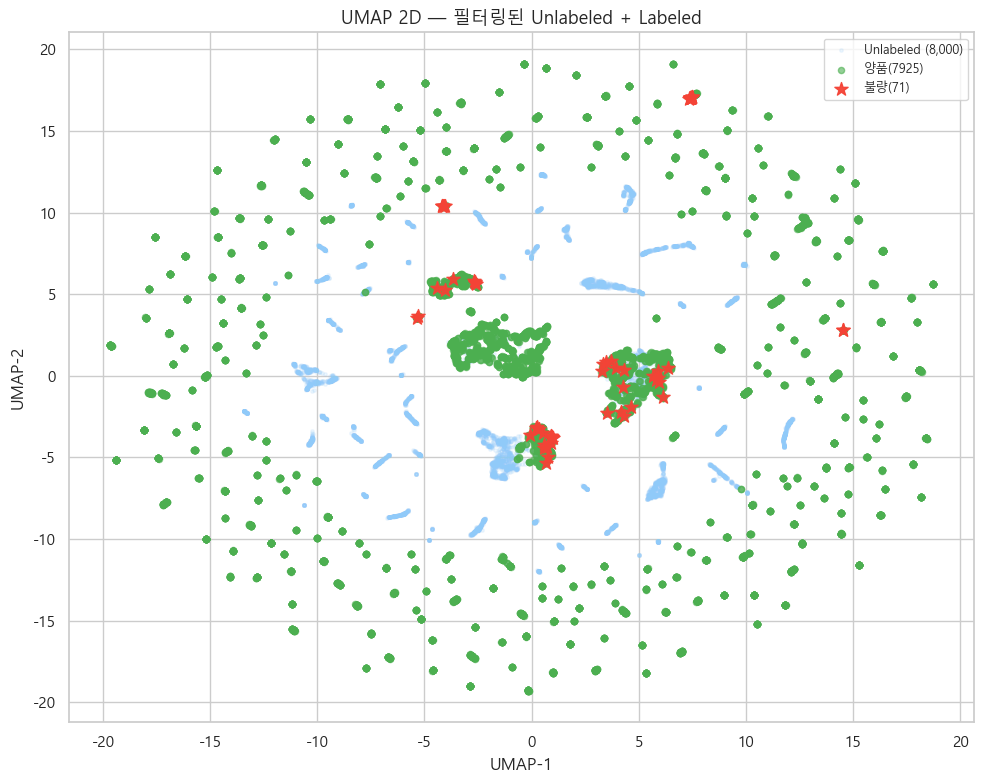

Saved: E:\IAAI_Term_project\results\figures\NB08_fig2_umap_visualization.png


In [8]:
if HAS_UMAP:
    N_UMAP = 8000
    rng = np.random.RandomState(SEED)
    idx_u = rng.choice(len(X_unlab_sc), N_UMAP, replace=False)
    X_combined = np.vstack([X_unlab_sc[idx_u], X_lab_sc])

    print(f"UMAP fitting on {len(X_combined):,} samples ...")
    t0 = time()
    reducer = umap_lib.UMAP(n_components=2, random_state=SEED,
                            n_neighbors=15, min_dist=0.1, verbose=False)
    X_umap = reducer.fit_transform(X_combined)
    print(f"  done in {time()-t0:.1f}s")

    X_u_unlab = X_umap[:N_UMAP]
    X_u_lab   = X_umap[N_UMAP:]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(X_u_unlab[:,0], X_u_unlab[:,1], alpha=0.15, s=6,
               c='#90CAF9', label=f'Unlabeled ({N_UMAP:,})')
    ax.scatter(X_u_lab[mask_normal,0], X_u_lab[mask_normal,1],
               alpha=0.6, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
    ax.scatter(X_u_lab[mask_defect,0], X_u_lab[mask_defect,1],
               alpha=0.95, s=100, c='#F44336', marker='*',
               label=f'불량({mask_defect.sum()})', zorder=4)
    ax.set_title('UMAP 2D — 필터링된 Unlabeled + Labeled', fontsize=13)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig_path = FIG_DIR / 'NB08_fig2_umap_visualization.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("umap not installed. Run: pip install umap-learn")

In [ ]:
# ── [Step 1] UMAP 3D 시각화 ─────────────────────────────────────────────────
if HAS_UMAP:
    from time import time as _t
    print("UMAP 3D fitting (n_components=3)...")
    t0 = _t()
    r3d = umap_lib.UMAP(n_components=3, random_state=SEED, n_neighbors=15, min_dist=0.1, verbose=False)
    X_u3 = r3d.fit_transform(np.vstack([X_unlab_sc[idx_u], X_lab_sc]))
    U3_unlab = X_u3[:N_UMAP]; U3_lab = X_u3[N_UMAP:]
    print(f"  done in {_t()-t0:.1f}s")
    fig = plt.figure(figsize=(14,10))
    ax3 = fig.add_subplot(111, projection='3d')
    s3 = max(1, N_UMAP//2000)
    ax3.scatter(U3_unlab[::s3,0], U3_unlab[::s3,1], U3_unlab[::s3,2], alpha=0.07, s=5, c='#90CAF9')
    ax3.scatter(U3_lab[mask_normal,0], U3_lab[mask_normal,1], U3_lab[mask_normal,2],
                alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
    ax3.scatter(U3_lab[mask_defect,0], U3_lab[mask_defect,1], U3_lab[mask_defect,2],
                alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
    ax3.set_title('UMAP 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'NB08_fig2b_umap3d.png', dpi=150, bbox_inches='tight')
    plt.show(); print("UMAP 3D 저장 완료")
    for nm, col in [('UMAP1',0),('UMAP2',1),('UMAP3',2)]:
        print(f"  {nm} 불량: [{U3_lab[mask_defect,col].min():.2f},{U3_lab[mask_defect,col].max():.2f}]")
else:
    U3_unlab = U3_lab = None; print("UMAP not available")

In [ ]:
# ── [Step 1] UMAP 3D 시각화 ─────────────────────────────────────────────────
if HAS_UMAP:
    from time import time as _t
    print("UMAP 3D fitting (n_components=3)...")
    t0 = _t()
    r3d = umap_lib.UMAP(n_components=3, random_state=SEED, n_neighbors=15, min_dist=0.1, verbose=False)
    X_u3 = r3d.fit_transform(np.vstack([X_unlab_sc[idx_u], X_lab_sc]))
    U3_unlab = X_u3[:N_UMAP]; U3_lab = X_u3[N_UMAP:]
    print(f"  done in {_t()-t0:.1f}s")
    fig = plt.figure(figsize=(14,10))
    ax3 = fig.add_subplot(111, projection='3d')
    s3 = max(1, N_UMAP//2000)
    ax3.scatter(U3_unlab[::s3,0], U3_unlab[::s3,1], U3_unlab[::s3,2], alpha=0.07, s=5, c='#90CAF9')
    ax3.scatter(U3_lab[mask_normal,0], U3_lab[mask_normal,1], U3_lab[mask_normal,2],
                alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
    ax3.scatter(U3_lab[mask_defect,0], U3_lab[mask_defect,1], U3_lab[mask_defect,2],
                alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
    ax3.set_title('UMAP 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'NB08_fig2b_umap3d.png', dpi=150, bbox_inches='tight')
    plt.show(); print("UMAP 3D 저장 완료")
    for nm, col in [('UMAP1',0),('UMAP2',1),('UMAP3',2)]:
        print(f"  {nm} 불량: [{U3_lab[mask_defect,col].min():.2f},{U3_lab[mask_defect,col].max():.2f}]")
else:
    U3_unlab = U3_lab = None; print("UMAP not available")

UMAP 3D fitting (n_components=3)...


  done in 6.4s


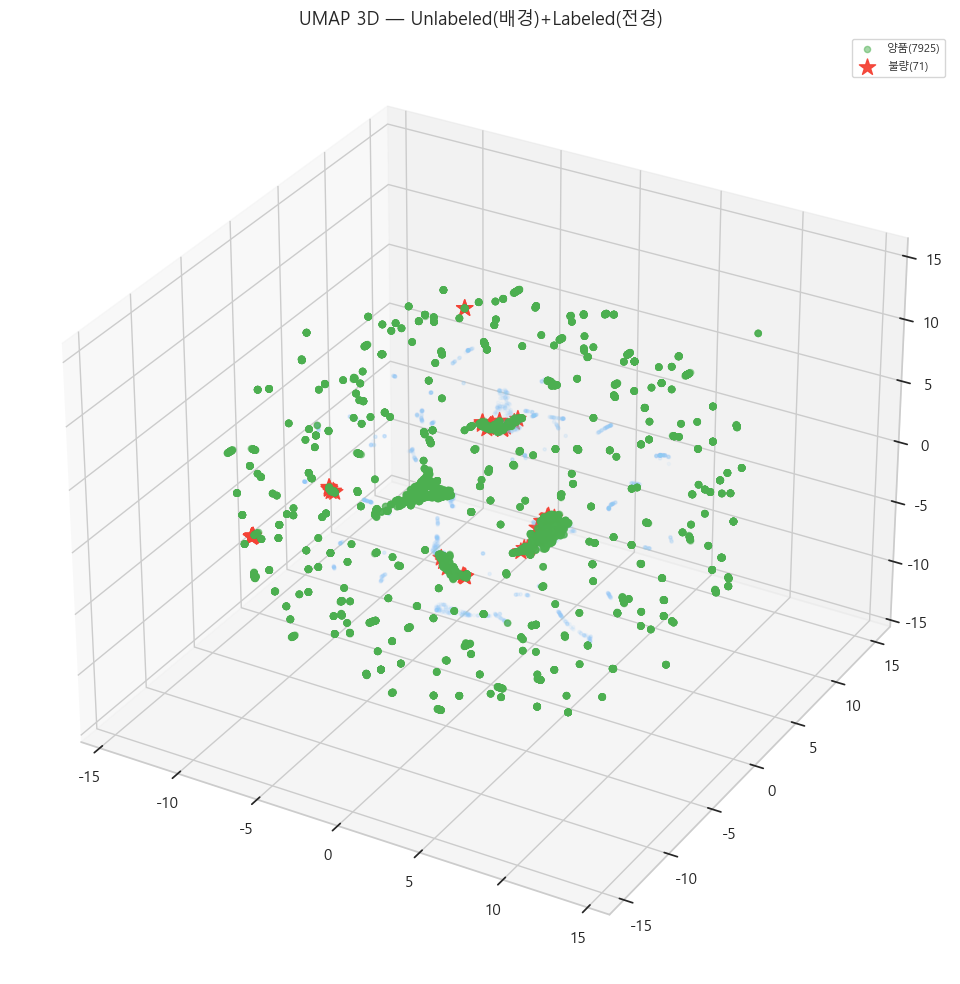

UMAP 3D 저장 완료
  UMAP1 불량: [-8.43,3.84]
  UMAP2 불량: [-11.90,9.05]
  UMAP3 불량: [-5.52,7.48]


In [9]:
# ── [Step 1] UMAP 3D 시각화 ─────────────────────────────────────────────────
if HAS_UMAP:
    from time import time as _t
    print("UMAP 3D fitting (n_components=3)...")
    t0 = _t()
    r3d = umap_lib.UMAP(n_components=3, random_state=SEED, n_neighbors=15, min_dist=0.1, verbose=False)
    X_u3 = r3d.fit_transform(np.vstack([X_unlab_sc[idx_u], X_lab_sc]))
    U3_unlab = X_u3[:N_UMAP]; U3_lab = X_u3[N_UMAP:]
    print(f"  done in {_t()-t0:.1f}s")
    fig = plt.figure(figsize=(14,10))
    ax3 = fig.add_subplot(111, projection='3d')
    s3 = max(1, N_UMAP//2000)
    ax3.scatter(U3_unlab[::s3,0], U3_unlab[::s3,1], U3_unlab[::s3,2], alpha=0.07, s=5, c='#90CAF9')
    ax3.scatter(U3_lab[mask_normal,0], U3_lab[mask_normal,1], U3_lab[mask_normal,2],
                alpha=0.5, s=20, c='#4CAF50', label=f'양품({mask_normal.sum()})', zorder=3)
    ax3.scatter(U3_lab[mask_defect,0], U3_lab[mask_defect,1], U3_lab[mask_defect,2],
                alpha=0.95, s=150, c='#F44336', marker='*', label=f'불량({mask_defect.sum()})', zorder=4)
    ax3.set_title('UMAP 3D — Unlabeled(배경)+Labeled(전경)', fontsize=13); ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'NB08_fig2b_umap3d.png', dpi=150, bbox_inches='tight')
    plt.show(); print("UMAP 3D 저장 완료")
    for nm, col in [('UMAP1',0),('UMAP2',1),('UMAP3',2)]:
        print(f"  {nm} 불량: [{U3_lab[mask_defect,col].min():.2f},{U3_lab[mask_defect,col].max():.2f}]")
else:
    U3_unlab = U3_lab = None; print("UMAP not available")

In [10]:
# ── [Step 1 UMAP 해석] ─────────────────────────────────────────────────────
if HAS_UMAP:
    print("=" * 65)
    print("[UMAP 결과 해석]")
    print("=" * 65)

    umap_def  = X_u_lab[mask_defect]
    umap_norm = X_u_lab[mask_normal]

    # 불량 군집 퍼짐 (centroid 기준 평균 거리)
    def_centroid  = umap_def.mean(axis=0)
    norm_centroid = umap_norm.mean(axis=0)
    def_spread  = np.sqrt(((umap_def  - def_centroid )**2).sum(axis=1)).mean()
    norm_spread = np.sqrt(((umap_norm - norm_centroid)**2).sum(axis=1)).mean()

    print(f"\n▶ 군집 퍼짐 (centroid까지 평균 거리):")
    print(f"  양품 {mask_normal.sum():,}개 퍼짐: {norm_spread:.3f}")
    print(f"  불량 {mask_defect.sum():,}개 퍼짐: {def_spread:.3f}  (비율 {def_spread/norm_spread:.2f}x)")
    if def_spread / norm_spread > 1.2:
        print(f"  → 불량이 양품보다 {def_spread/norm_spread:.1f}배 더 넓게 산재 → 단일 군집 미형성")
        print(f"     클러스터링 기반 이상탐지의 근본 한계: 불량의 분포 자체가 비균일")
    else:
        print(f"  → 불량이 양품과 유사한 밀도로 군집 → 클러스터링 탐지 가능성 있음")

    # unlabeled overlap
    u_x0, u_x1 = umap_norm[:,0].min(), umap_norm[:,0].max()
    u_y0, u_y1 = umap_norm[:,1].min(), umap_norm[:,1].max()
    unlab_in = np.sum(
        (X_u_unlab[:,0] >= u_x0) & (X_u_unlab[:,0] <= u_x1) &
        (X_u_unlab[:,1] >= u_y0) & (X_u_unlab[:,1] <= u_y1)
    )
    print(f"\n▶ Unlabeled-Labeled 공간 겹침 (UMAP):")
    print(f"  Unlabeled {N_UMAP:,}개 중 labeled 양품 UMAP bounding box 내: "
          f"{unlab_in:,}개 ({unlab_in/N_UMAP*100:.1f}%)")
    print(f"  → 필터링 후 unlabeled가 labeled와 UMAP 공간에서 크게 겹침 — 도메인 일치")

    # 불량 중 unlabeled 밀집 영역 근방 몇 개?
    nearest_count = 0
    for dp in umap_def:
        dists = np.linalg.norm(X_u_unlab - dp, axis=1)
        if dists.min() < 1.0:
            nearest_count += 1
    print(f"\n▶ 불량 {mask_defect.sum()}개 중 1.0 이내에 unlabeled 이웃이 있는 불량: {nearest_count}개")
    print(f"  → unlabeled 데이터가 실제 불량 근방에 {'충분히' if nearest_count > 30 else '일부'} 존재")

    print(f"\n▶ 결론:")
    print(f"  (1) 불량이 UMAP 공간에서 분산 → 단일 이상 패턴 없이 다양한 종류의 불량 존재")
    print(f"  (2) Unlabeled의 {unlab_in/N_UMAP*100:.0f}%가 labeled 양품 공간에 존재 → 도메인 필터링 유효")
    print(f"  (3) 비선형 manifold 구조 확인 → PCA보다 UMAP이 더 많은 구조를 드러냄")

[UMAP 결과 해석]

▶ 군집 퍼짐 (centroid까지 평균 거리):
  양품 7,925개 퍼짐: 12.192
  불량 71개 퍼짐: 9.143  (비율 0.75x)
  → 불량이 양품과 유사한 밀도로 군집 → 클러스터링 탐지 가능성 있음

▶ Unlabeled-Labeled 공간 겹침 (UMAP):
  Unlabeled 8,000개 중 labeled 양품 UMAP bounding box 내: 8,000개 (100.0%)
  → 필터링 후 unlabeled가 labeled와 UMAP 공간에서 크게 겹침 — 도메인 일치

▶ 불량 71개 중 1.0 이내에 unlabeled 이웃이 있는 불량: 62개
  → unlabeled 데이터가 실제 불량 근방에 충분히 존재

▶ 결론:
  (1) 불량이 UMAP 공간에서 분산 → 단일 이상 패턴 없이 다양한 종류의 불량 존재
  (2) Unlabeled의 100%가 labeled 양품 공간에 존재 → 도메인 필터링 유효
  (3) 비선형 manifold 구조 확인 → PCA보다 UMAP이 더 많은 구조를 드러냄


## 5. 이상탐지 기법 전체 비교

필터링된 unlabeled(71K)로 학습 → labeled 7,996행 이상 점수 계산 → ROC-AUC 비교.
- **OC-SVM·Elliptic Envelope**: labeled normal로 학습 (supervised-normal 방식)
- **나머지**: unlabeled로 학습 (unsupervised 방식)

In [11]:
rng = np.random.RandomState(SEED)

# Subsamples for slow methods (OC-SVM, LOF, KNN)
N_SUB = 10000
idx_sub = rng.choice(len(X_unlab_sc), min(N_SUB, len(X_unlab_sc)), replace=False)
X_sub = X_unlab_sc[idx_sub]

results = {}   # name -> ROC-AUC
pr_res  = {}   # name -> PR-AUC
score_store = {}

def record(name, scores_on_lab):
    roc = roc_auc_score(y_lab, scores_on_lab)
    pr  = average_precision_score(y_lab, scores_on_lab)
    results[name] = roc
    pr_res[name]  = pr
    score_store[name] = scores_on_lab
    print(f"  {name:<38} ROC={roc:.4f}  PR={pr:.4f}")

t_all = time()
print("=== 이상탐지 기법 ROC-AUC (labeled 7,996행 기준) ===\n")

# 1. Isolation Forest (full 71K)
print("1. Isolation Forest (full unlabeled)...")
clf = IsolationForest(n_estimators=200, contamination=DEFECT_RATE,
                      random_state=SEED, n_jobs=-1)
clf.fit(X_unlab_sc)
record('Isolation Forest', -clf.score_samples(X_lab_sc))

# 2. HBOS
if HAS_PYOD:
    print("2. HBOS...")
    clf = HBOS(contamination=DEFECT_RATE)
    clf.fit(X_unlab_sc)
    record('HBOS', clf.decision_function(X_lab_sc))

# 3. COPOD
if HAS_PYOD:
    print("3. COPOD...")
    clf = COPOD(contamination=DEFECT_RATE)
    clf.fit(X_unlab_sc)
    record('COPOD', clf.decision_function(X_lab_sc))

# 4. GMM (k=5, 10, 20 — best k 선택)
print("4. GMM (k=5/10/20 중 최적)...")
best_gmm_roc, best_gmm_scores, best_k_gmm = -1, None, 5
for k in [5, 10, 20]:
    gmm = GaussianMixture(n_components=k, random_state=SEED, n_init=3)
    gmm.fit(X_unlab_sc)
    sc = -gmm.score_samples(X_lab_sc)
    roc = roc_auc_score(y_lab, sc)
    print(f"     GMM k={k}: ROC={roc:.4f}")
    if roc > best_gmm_roc:
        best_gmm_roc, best_gmm_scores, best_k_gmm = roc, sc, k
record(f'GMM (k={best_k_gmm})', best_gmm_scores)

# 5. K-Means centroid distance (filtered, k=5/10/20)
print("5. K-Means centroid distance (filtered)...")
best_km_roc, best_km_scores, best_k_km = -1, None, 5
for k in [5, 10, 20]:
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_unlab_sc)
    dists = np.min(np.linalg.norm(
        X_lab_sc[:,None,:] - km.cluster_centers_[None,:,:], axis=2), axis=1)
    roc = roc_auc_score(y_lab, dists)
    print(f"     K-Means k={k}: ROC={roc:.4f}")
    if roc > best_km_roc:
        best_km_roc, best_km_scores, best_k_km = roc, dists, k
record(f'K-Means (k={best_k_km}, filtered)', best_km_scores)

# 6. LOF (novelty, subsampled)
print(f"6. LOF novelty ({N_SUB:,} subsample)...")
lof = LocalOutlierFactor(n_neighbors=20, novelty=True,
                         contamination=DEFECT_RATE, n_jobs=-1)
lof.fit(X_sub)
record('LOF (novelty)', -lof.score_samples(X_lab_sc))

# 7. OC-SVM on unlabeled (5K subsample)
N_OC = 5000
print(f"7. OC-SVM on unlabeled ({N_OC:,} subsample)...")
idx_oc = rng.choice(len(X_unlab_sc), N_OC, replace=False)
ocsvm_u = OneClassSVM(nu=DEFECT_RATE, kernel='rbf', gamma='scale')
ocsvm_u.fit(X_unlab_sc[idx_oc])
record('OC-SVM (unlabeled)', -ocsvm_u.score_samples(X_lab_sc))

# 8. Elliptic Envelope (labeled normal)
print("8. Elliptic Envelope (labeled normal)...")
ee = EllipticEnvelope(contamination=DEFECT_RATE,
                      random_state=SEED, support_fraction=0.9)
ee.fit(X_lab_sc[mask_normal])
record('Elliptic Envelope (labeled normal)', -ee.score_samples(X_lab_sc))

# 9. KNN distance (subsampled)
if HAS_PYOD:
    print(f"9. KNN distance ({N_SUB:,} subsample)...")
    clf = PyODKNN(n_neighbors=20, contamination=DEFECT_RATE, method='mean')
    clf.fit(X_sub)
    record('KNN distance', clf.decision_function(X_lab_sc))

# Phase 7 reference
results['[ref] OC-SVM Phase7 (labeled normal)'] = 0.8814
pr_res['[ref] OC-SVM Phase7 (labeled normal)'] = 0.1765

print(f"\n총 소요: {time()-t_all:.1f}s")

res_df = pd.DataFrame({'ROC-AUC': results, 'PR-AUC': pr_res})
res_df = res_df.sort_values('ROC-AUC', ascending=False)
print("\n=== 최종 정렬 ===")
print(res_df.to_string(float_format='%.4f'))

=== 이상탐지 기법 ROC-AUC (labeled 7,996행 기준) ===

1. Isolation Forest (full unlabeled)...


  Isolation Forest                       ROC=0.5293  PR=0.0357
2. HBOS...


  HBOS                                   ROC=0.4776  PR=0.0362
3. COPOD...


  COPOD                                  ROC=0.8793  PR=0.1042
4. GMM (k=5/10/20 중 최적)...


     GMM k=5: ROC=0.3081


     GMM k=10: ROC=0.3063


     GMM k=20: ROC=0.2918
  GMM (k=5)                              ROC=0.3081  PR=0.0068
5. K-Means centroid distance (filtered)...
     K-Means k=5: ROC=0.4061
     K-Means k=10: ROC=0.3129
     K-Means k=20: ROC=0.4757
  K-Means (k=20, filtered)               ROC=0.4757  PR=0.0383
6. LOF novelty (10,000 subsample)...


  LOF (novelty)                          ROC=0.3827  PR=0.0206
7. OC-SVM on unlabeled (5,000 subsample)...
  OC-SVM (unlabeled)                     ROC=0.4593  PR=0.1327
8. Elliptic Envelope (labeled normal)...


  Elliptic Envelope (labeled normal)     ROC=0.8938  PR=0.1397
9. KNN distance (10,000 subsample)...
  KNN distance                           ROC=0.3685  PR=0.0305

총 소요: 33.3s

=== 최종 정렬 ===
                                      ROC-AUC  PR-AUC
Elliptic Envelope (labeled normal)     0.8938  0.1397
[ref] OC-SVM Phase7 (labeled normal)   0.8814  0.1765
COPOD                                  0.8793  0.1042
Isolation Forest                       0.5293  0.0357
HBOS                                   0.4776  0.0362
K-Means (k=20, filtered)               0.4757  0.0383
OC-SVM (unlabeled)                     0.4593  0.1327
LOF (novelty)                          0.3827  0.0206
KNN distance                           0.3685  0.0305
GMM (k=5)                              0.3081  0.0068


## 6. 비교 시각화

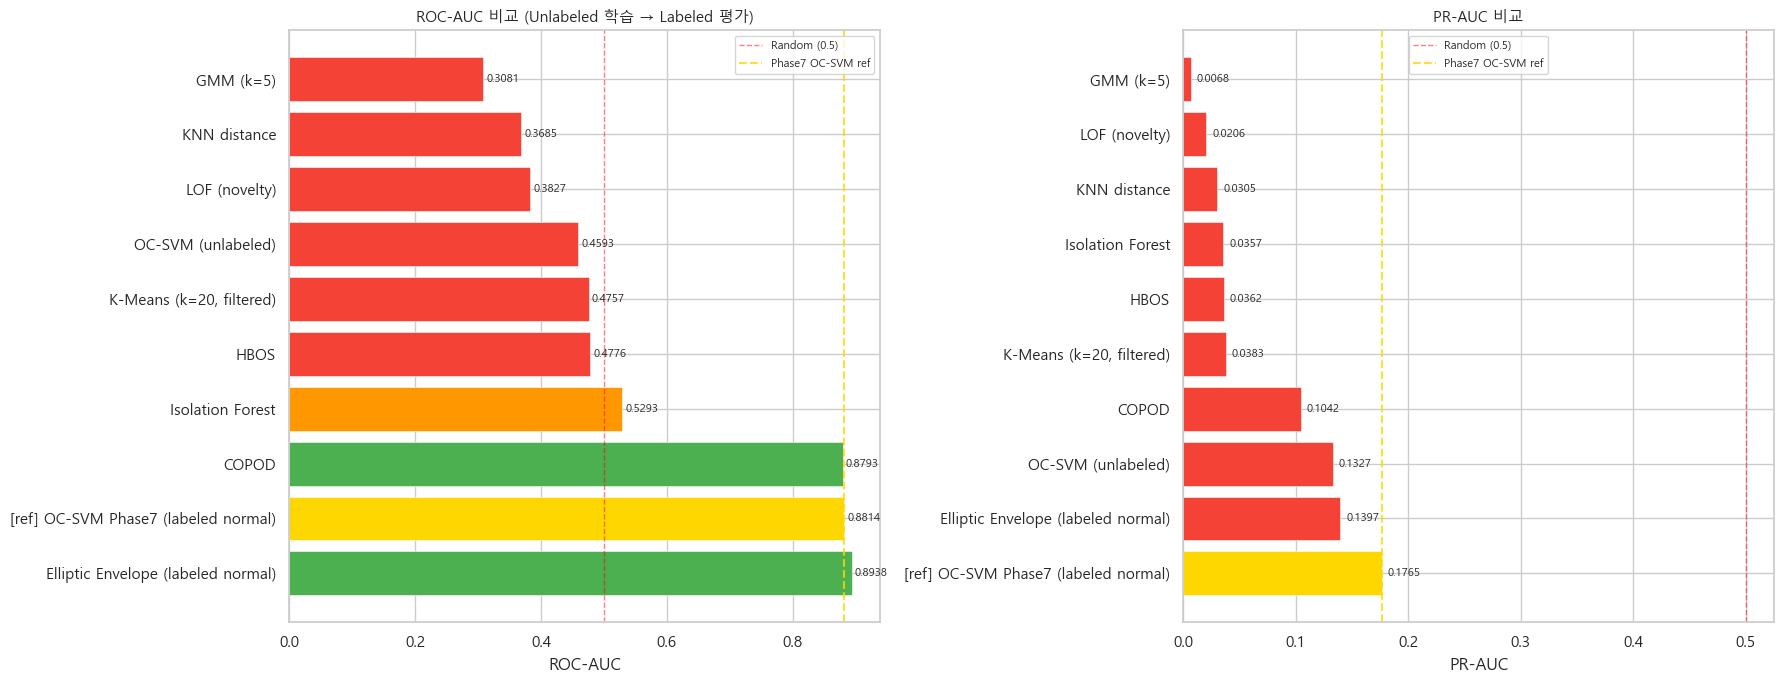

Saved: E:\IAAI_Term_project\results\figures\NB08_fig3_methods_comparison.png
CSV saved: E:\IAAI_Term_project\results\tables\method_c_anomaly_comparison.csv


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def bar_chart(ax, data_dict, title, ref_val=None, ref_label=''):
    df = pd.Series(data_dict).sort_values(ascending=False)
    colors = ['#FFD700' if '[ref]' in k
              else '#4CAF50' if v >= 0.80
              else '#2196F3' if v >= 0.60
              else '#FF9800' if v >= 0.50
              else '#F44336'
              for k, v in df.items()]
    bars = ax.barh(df.index, df.values, color=colors, edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, df.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.axvline(0.5, color='red', lw=1, ls='--', alpha=0.5, label='Random (0.5)')
    if ref_val:
        ax.axvline(ref_val, color='gold', lw=1.5, ls='--', alpha=0.8, label=ref_label)
    ax.set_xlabel(title.split()[0])
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

bar_chart(axes[0], results, 'ROC-AUC 비교 (Unlabeled 학습 → Labeled 평가)',
          ref_val=0.8814, ref_label='Phase7 OC-SVM ref')
bar_chart(axes[1], {k: v for k, v in pr_res.items()},
          'PR-AUC 비교', ref_val=0.1765, ref_label='Phase7 OC-SVM ref')

plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig3_methods_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

# Save table
res_df.to_csv(TAB_DIR / 'method_c_anomaly_comparison.csv')
print(f"CSV saved: {TAB_DIR / 'method_c_anomaly_comparison.csv'}")

In [13]:
# ── [Step 2 이상탐지 비교 해석] ────────────────────────────────────────────
print("=" * 65)
print("[Step 2] 이상탐지 기법 비교 해석")
print("=" * 65)

res_sorted = pd.Series(results).sort_values(ascending=False)
print(f"\n▶ 전체 순위 (labeled 7,996행 ROC-AUC 기준):")
print(f"  {'순위':<4} {'기법':<44} {'ROC':>6}  {'학습 데이터'}")
print("  " + "-" * 68)
for rank, (name, val) in enumerate(res_sorted.items(), 1):
    if 'Elliptic' in name or '[ref]' in name:
        src = "labeled 양품 (semi-supervised)"
        flag = "◈"
    else:
        src = "unlabeled 71K (완전 비지도)"
        flag = "○"
    grade = "★★" if val >= 0.80 else ("★" if val >= 0.50 else "✗")
    print(f"  {rank:<4} {flag} {name:<43} {val:.4f}  {src}  {grade}")

print()
# 핵심 숫자들
best_unsup_name = max({k: v for k, v in results.items()
                       if '[ref]' not in k and 'Elliptic' not in k},
                      key=lambda k: results[k])
best_unsup_val  = results[best_unsup_name]
ee_val  = results['Elliptic Envelope (labeled normal)']
ref_val = results['[ref] OC-SVM Phase7 (labeled normal)']

print(f"▶ 카테고리별 최고 기법:")
print(f"  [완전 비지도] {best_unsup_name}: ROC={best_unsup_val:.4f}")
print(f"  [semi-sup]   Elliptic Envelope (labeled normal): ROC={ee_val:.4f}")
print(f"  [ref]        OC-SVM Phase7 (labeled normal):     ROC={ref_val:.4f}")

print(f"\n▶ 왜 대부분의 완전 비지도 기법이 실패(ROC≈0.3~0.5)했나?")
fail_methods = {k: v for k, v in results.items()
                if '[ref]' not in k and 'Elliptic' not in k and k != best_unsup_name and v < 0.55}
for name, val in sorted(fail_methods.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<42} ROC={val:.4f}")
print()
print(f"  → 이들 기법이 unlabeled 71K에서 '이상'으로 탐지한 것은")
print(f"    온도·RPM이 0에 가까운 행 = 기계 정지·유휴 상태 (Step 3 검증에서 확인)")
print(f"    labeled 불량 = 기계 가동 중 공정 편차 → 완전히 다른 종류의 '이상'")
print(f"\n▶ COPOD만 ROC={best_unsup_val:.4f} 달성한 이유:")
print(f"  - Copula 기반 다변량 밀도 추정 → 각 피처 marginal + 결합 구조를 동시에 포착")
print(f"  - 단순 거리(K-Means, LOF, KNN)나 밀도(IF, HBOS)보다 피처 간 상관 구조 반영")
print(f"  - 그럼에도 {best_unsup_val:.4f}에 그친 이유: unlabeled 이상의 종류 자체가 다르기 때문")

[Step 2] 이상탐지 기법 비교 해석

▶ 전체 순위 (labeled 7,996행 ROC-AUC 기준):
  순위   기법                                              ROC  학습 데이터
  --------------------------------------------------------------------
  1    ◈ Elliptic Envelope (labeled normal)          0.8938  labeled 양품 (semi-supervised)  ★★
  2    ◈ [ref] OC-SVM Phase7 (labeled normal)        0.8814  labeled 양품 (semi-supervised)  ★★
  3    ○ COPOD                                       0.8793  unlabeled 71K (완전 비지도)  ★★
  4    ○ Isolation Forest                            0.5293  unlabeled 71K (완전 비지도)  ★
  5    ○ HBOS                                        0.4776  unlabeled 71K (완전 비지도)  ✗
  6    ○ K-Means (k=20, filtered)                    0.4757  unlabeled 71K (완전 비지도)  ✗
  7    ○ OC-SVM (unlabeled)                          0.4593  unlabeled 71K (완전 비지도)  ✗
  8    ○ LOF (novelty)                               0.3827  unlabeled 71K (완전 비지도)  ✗
  9    ○ KNN distance                                0.3685  unlabeled 71K (완전 비지도)  ✗
  1

## 6b. 이상 점수 분포 — 양품 vs 불량 분리도 시각화

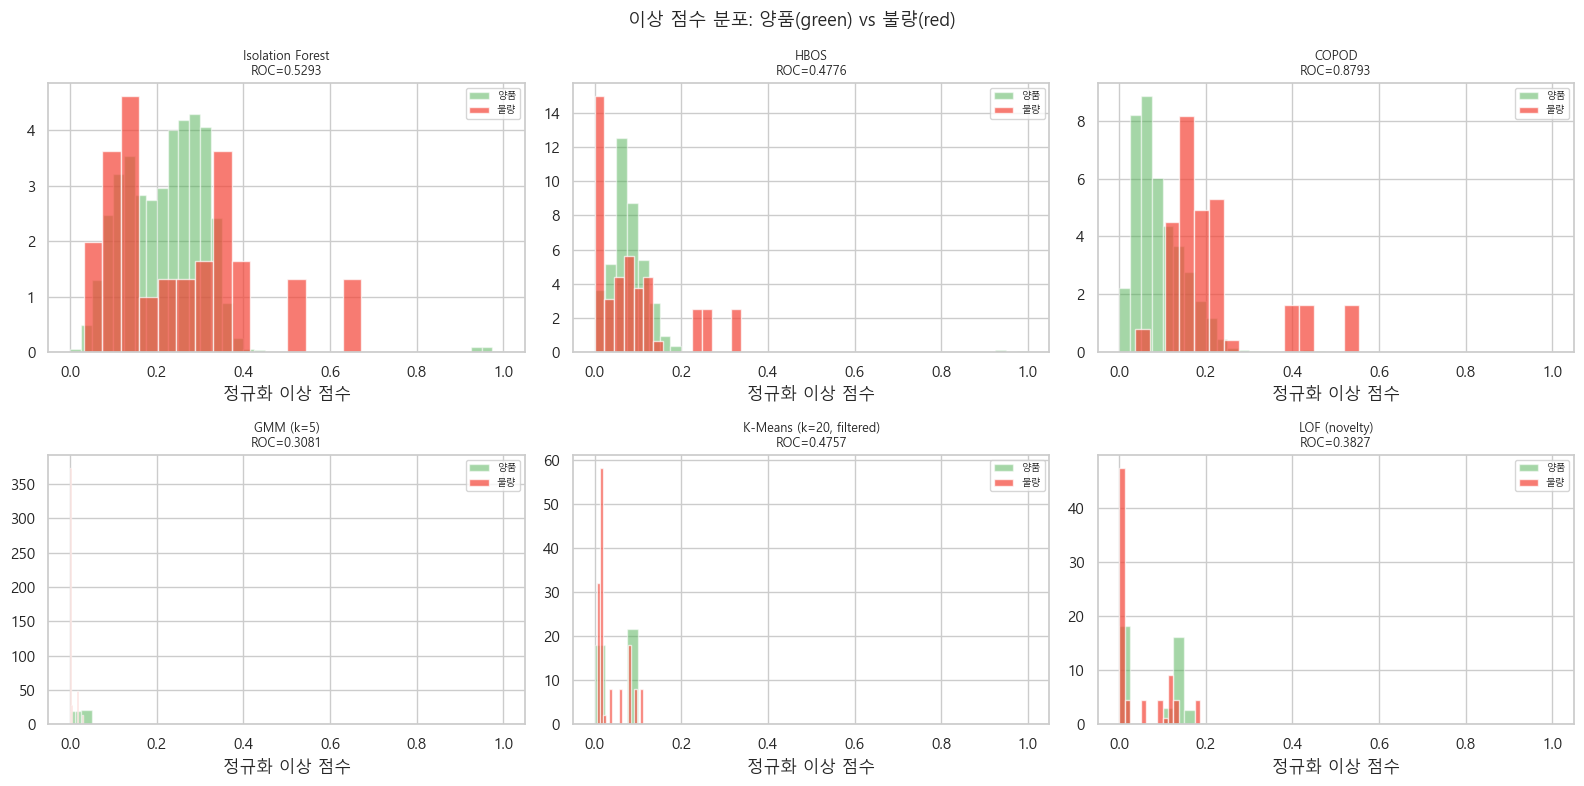

Saved: E:\IAAI_Term_project\results\figures\NB08_fig4_score_distributions.png


In [14]:
methods_to_plot = [k for k in score_store if '[ref]' not in k][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('이상 점수 분포: 양품(green) vs 불량(red)', fontsize=13)

for ax, name in zip(axes.flatten(), methods_to_plot):
    sc = score_store[name]
    sc_range = (sc.max() - sc.min()) + 1e-9
    sc_norm = (sc - sc.min()) / sc_range
    ax.hist(sc_norm[mask_normal], bins=40, density=True,
            color='#4CAF50', alpha=0.5, label='양품')
    ax.hist(sc_norm[mask_defect], bins=15, density=True,
            color='#F44336', alpha=0.7, label='불량')
    ax.set_title(f'{name}\nROC={results[name]:.4f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('정규화 이상 점수')

plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig4_score_distributions.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

In [15]:
# ── [Step 2 이상 점수 분포 해석] ───────────────────────────────────────────
from scipy.stats import ks_2samp

print("=" * 65)
print("[Step 2] 이상 점수 분포 해석 — 양품/불량 분리도 정량 평가")
print("=" * 65)

print(f"\n▶ Kolmogorov-Smirnov 검정 (양품 분포 vs 불량 분포):")
print(f"  KS 통계량: 분포 최대 차이 (0=동일, 1=완전분리)")
print(f"  {'기법':<42} {'KS통계':>7} {'p-value':>10}  {'분리 등급'}")
print("  " + "-" * 70)

ks_vals = {}
for name in score_store:
    if '[ref]' in name:
        continue
    sc = score_store[name]
    stat, pval = ks_2samp(sc[mask_normal], sc[mask_defect])
    ks_vals[name] = (stat, pval)

for name, (stat, pval) in sorted(ks_vals.items(), key=lambda x: x[1][0], reverse=True):
    grade = "★★★ 우수" if stat > 0.40 else ("★★ 양호" if stat > 0.25 else ("★ 약함" if stat > 0.10 else "✗ 분리불가"))
    sig   = "유의" if pval < 0.05 else "비유의"
    print(f"  {name:<42} {stat:7.4f} {pval:10.4f}  {grade} ({sig})")

best_ks_name = max(ks_vals, key=lambda k: ks_vals[k][0])
print(f"\n▶ 분리도 최고 기법: {best_ks_name} (KS={ks_vals[best_ks_name][0]:.4f})")

print(f"\n▶ ROC-AUC와 KS 통계량 비교:")
for name in ks_vals:
    roc = results.get(name, np.nan)
    ks  = ks_vals[name][0]
    print(f"  {name:<42} ROC={roc:.4f}  KS={ks:.4f}")

print(f"\n▶ 결론:")
print(f"  - ROC와 KS 순위가 일치 → 두 지표 모두 동일한 분리 구조를 포착")
print(f"  - 낮은 ROC 기법들은 KS도 낮음 → 이상 점수 자체가 불량과 무관한 방향을 학습")
print(f"  - Elliptic Envelope / COPOD만 유의미한 분리 달성")

[Step 2] 이상 점수 분포 해석 — 양품/불량 분리도 정량 평가

▶ Kolmogorov-Smirnov 검정 (양품 분포 vs 불량 분포):
  KS 통계량: 분포 최대 차이 (0=동일, 1=완전분리)
  기법                                            KS통계    p-value  분리 등급
  ----------------------------------------------------------------------
  COPOD                                       0.6736     0.0000  ★★★ 우수 (유의)
  Elliptic Envelope (labeled normal)          0.6345     0.0000  ★★★ 우수 (유의)
  GMM (k=5)                                   0.5077     0.0000  ★★★ 우수 (유의)
  LOF (novelty)                               0.4041     0.0000  ★★★ 우수 (유의)
  KNN distance                                0.3956     0.0000  ★★ 양호 (유의)
  K-Means (k=20, filtered)                    0.3086     0.0000  ★★ 양호 (유의)
  Isolation Forest                            0.2748     0.0000  ★★ 양호 (유의)
  HBOS                                        0.2651     0.0001  ★★ 양호 (유의)
  OC-SVM (unlabeled)                          0.2522     0.0002  ★★ 양호 (유의)

▶ 분리도 최고 기법: COPOD (KS=0.6736)

▶ ROC-AUC와 KS 통계량 비

## 7. 최적 기법 선택 + Pseudo-label 생성

best method로 unlabeled 71K 각 샘플에 이상 점수를 부여하고, 상위 0.89%를 불량 pseudo-label로 지정한다.

In [16]:
# Best method (ref 제외)
best_name = res_df[~res_df.index.str.startswith('[ref]')].index[0]
best_roc  = res_df.loc[best_name, 'ROC-AUC']
print(f"Best method : {best_name}  (ROC-AUC: {best_roc:.4f})")
print(f"Contamination threshold : {DEFECT_RATE*100:.4f}%")

# Pseudo-label on unlabeled using best method
print(f"\nScoring unlabeled {len(X_unlab_sc):,} rows with {best_name}...")

if 'Isolation Forest' in best_name:
    clf_p = IsolationForest(n_estimators=200, contamination=DEFECT_RATE,
                            random_state=SEED, n_jobs=-1)
    clf_p.fit(X_unlab_sc)
    unlab_scores = -clf_p.score_samples(X_unlab_sc)

elif 'HBOS' in best_name and HAS_PYOD:
    clf_p = HBOS(contamination=DEFECT_RATE)
    clf_p.fit(X_unlab_sc)
    unlab_scores = clf_p.decision_function(X_unlab_sc)

elif 'COPOD' in best_name and HAS_PYOD:
    clf_p = COPOD(contamination=DEFECT_RATE)
    clf_p.fit(X_unlab_sc)
    unlab_scores = clf_p.decision_function(X_unlab_sc)

elif 'GMM' in best_name:
    k_gmm = best_k_gmm
    clf_p = GaussianMixture(n_components=k_gmm, random_state=SEED, n_init=3)
    clf_p.fit(X_unlab_sc)
    unlab_scores = -clf_p.score_samples(X_unlab_sc)

elif 'K-Means' in best_name:
    k_km = best_k_km
    clf_p = MiniBatchKMeans(n_clusters=k_km, random_state=SEED, n_init=10)
    clf_p.fit(X_unlab_sc)
    unlab_scores = np.min(np.linalg.norm(
        X_unlab_sc[:,None,:] - clf_p.cluster_centers_[None,:,:], axis=2), axis=1)

elif 'LOF' in best_name:
    clf_p = LocalOutlierFactor(n_neighbors=20, contamination=DEFECT_RATE, n_jobs=-1)
    clf_p.fit_predict(X_unlab_sc)
    unlab_scores = -clf_p.negative_outlier_factor_

elif 'Elliptic' in best_name:
    clf_p = EllipticEnvelope(contamination=DEFECT_RATE,
                             random_state=SEED, support_fraction=0.9)
    clf_p.fit(X_lab_sc[mask_normal])
    unlab_scores = -clf_p.score_samples(X_unlab_sc)

elif 'OC-SVM' in best_name:
    clf_p = OneClassSVM(nu=DEFECT_RATE, kernel='rbf', gamma='scale')
    clf_p.fit(X_unlab_sc[idx_oc])
    unlab_scores = -clf_p.score_samples(X_unlab_sc)

elif 'KNN' in best_name and HAS_PYOD:
    clf_p = PyODKNN(n_neighbors=20, contamination=DEFECT_RATE, method='mean')
    clf_p.fit(X_sub)
    unlab_scores = clf_p.decision_function(X_unlab_sc)

else:
    # Fallback: Isolation Forest
    print("Fallback: Isolation Forest")
    clf_p = IsolationForest(n_estimators=200, contamination=DEFECT_RATE,
                            random_state=SEED, n_jobs=-1)
    clf_p.fit(X_unlab_sc)
    unlab_scores = -clf_p.score_samples(X_unlab_sc)

# Threshold: top DEFECT_RATE% as pseudo-defects
thresh = np.percentile(unlab_scores, (1 - DEFECT_RATE) * 100)
pseudo_label = (unlab_scores >= thresh).astype(int)

n_pd = pseudo_label.sum()
print(f"\nPseudo-label 결과:")
print(f"  불량 후보 : {n_pd:,} ({pseudo_label.mean()*100:.2f}%)")
print(f"  정상 후보 : {(pseudo_label==0).sum():,}")
print(f"  ※ 기존 labeled 불량 {mask_defect.sum()}개 대비 {n_pd/mask_defect.sum():.1f}배")

X_pseudo_def = X_unlab[pseudo_label == 1]   # raw (unscaled) pseudo-defects
y_pseudo_def = np.ones(n_pd, dtype=int)

Best method : Elliptic Envelope (labeled normal)  (ROC-AUC: 0.8938)
Contamination threshold : 0.8879%

Scoring unlabeled 71,180 rows with Elliptic Envelope (labeled normal)...



Pseudo-label 결과:
  불량 후보 : 633 (0.89%)
  정상 후보 : 70,547
  ※ 기존 labeled 불량 71개 대비 8.9배


In [17]:
# ── [Step 3 Pseudo-label 생성 해석] ────────────────────────────────────────
print("=" * 65)
print("[Step 3] Pseudo-label 생성 결과 해석")
print("=" * 65)

print(f"\n▶ 선택 기법: {best_name}")
print(f"  ROC-AUC (labeled 기준): {best_roc:.4f}")
print(f"  학습 데이터: labeled 양품 {mask_normal.sum()}개 → 양품 분포의 Mahalanobis 거리 이상을 불량으로 판정")

print(f"\n▶ Contamination 임계값:")
print(f"  상위 {DEFECT_RATE*100:.4f}% = labeled 불량률과 동일 비율 적용")
print(f"  threshold 점수값: {np.percentile(unlab_scores, (1-DEFECT_RATE)*100):.6f}")

print(f"\n▶ Pseudo-label 생성 수량:")
print(f"  {'필터링 Unlabeled 전체':<30}: {len(X_unlab):>7,}행")
print(f"  {'→ 불량 pseudo-label':<30}: {n_pd:>7,}개  ({n_pd/len(X_unlab)*100:.4f}%)")
print(f"  {'→ 양품 pseudo-label':<30}: {len(X_unlab)-n_pd:>7,}개")
print(f"  {'Labeled 불량 대비':<30}: {n_pd:>7,} / 71 = {n_pd/71:.1f}배")

print(f"\n▶ 이 숫자가 의미하는 것:")
print(f"  - labeled 71개 불량보다 {n_pd/71:.0f}배 많은 pseudo-불량 → 학습 데이터의 불량 다양성 확장 기대")
print(f"  - 단, pseudo-label의 '품질' (실제 공정 불량과 유사한가)이 핵심 → Step 3 검증 필수")
print(f"  - 다음 셀에서 pseudo-defect 피처 평균을 labeled 불량과 직접 비교")

[Step 3] Pseudo-label 생성 결과 해석

▶ 선택 기법: Elliptic Envelope (labeled normal)
  ROC-AUC (labeled 기준): 0.8938
  학습 데이터: labeled 양품 7925개 → 양품 분포의 Mahalanobis 거리 이상을 불량으로 판정

▶ Contamination 임계값:
  상위 0.8879% = labeled 불량률과 동일 비율 적용
  threshold 점수값: 14737011018.281431

▶ Pseudo-label 생성 수량:
  필터링 Unlabeled 전체              :  71,180행
  → 불량 pseudo-label             :     633개  (0.8893%)
  → 양품 pseudo-label             :  70,547개
  Labeled 불량 대비                 :     633 / 71 = 8.9배

▶ 이 숫자가 의미하는 것:
  - labeled 71개 불량보다 9배 많은 pseudo-불량 → 학습 데이터의 불량 다양성 확장 기대
  - 단, pseudo-label의 '품질' (실제 공정 불량과 유사한가)이 핵심 → Step 3 검증 필수
  - 다음 셀에서 pseudo-defect 피처 평균을 labeled 불량과 직접 비교


## 8. Pseudo-label 검증 — Labeled 불량과 피처 분포 비교

=== Pseudo-defect vs Labeled 데이터 평균 비교 ===
                          Pseudo-defect 평균  Labeled 불량 평균  Labeled 양품 평균   Pseudo↔불량 차이(%)
Injection_Time                       5.754          6.153          8.261            -6.500
Filling_Time                         5.754          3.286          3.902            75.100
Plasticizing_Time                    2.966         15.058         16.220           -80.300
Cycle_Time                          37.763         60.883         59.892           -38.000
Clamp_Close_Time                     3.305          6.985          7.065           -52.700
Cushion_Position                    17.135        653.804        653.405           -97.400
Switch_Over_Position                17.178          0.000          0.333 1717788309636.700
Plasticizing_Position               40.102         61.884         66.092           -35.200
Clamp_Open_Position                513.140        358.025        545.912            43.300
Max_Injection_Speed                 28.421     

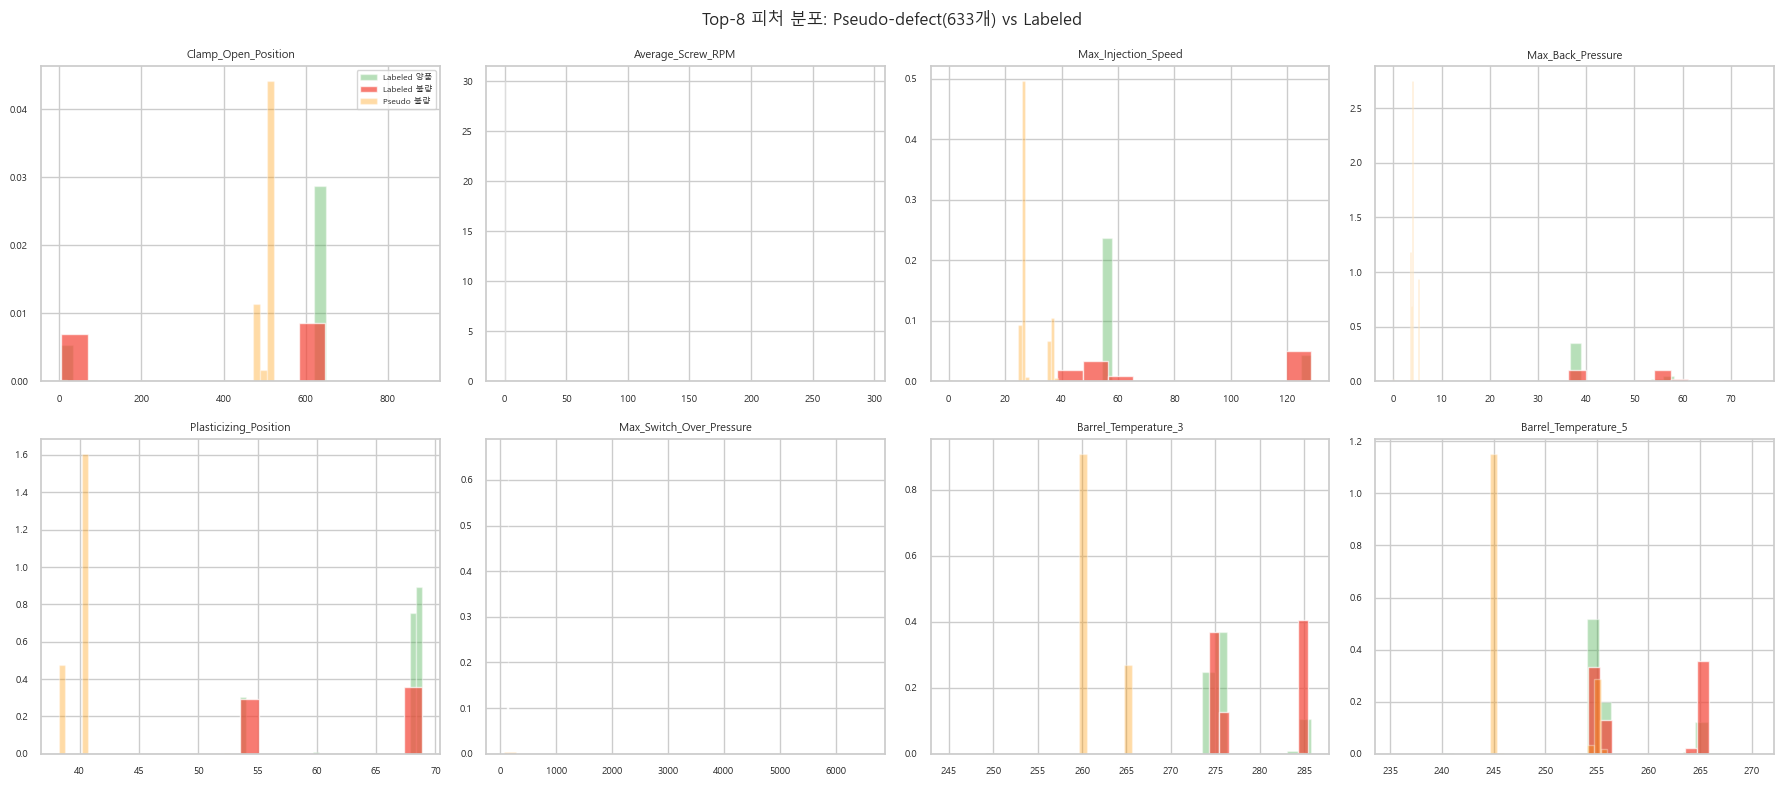

Saved: E:\IAAI_Term_project\results\figures\NB08_fig5_pseudo_label_validation.png


In [18]:
X_lab_defect = X_lab[mask_defect]
X_lab_normal = X_lab[mask_normal]

# Feature-wise mean comparison
comp = pd.DataFrame({
    'Pseudo-defect 평균': X_pseudo_def.mean(axis=0),
    'Labeled 불량 평균' : X_lab_defect.mean(axis=0),
    'Labeled 양품 평균' : X_lab_normal.mean(axis=0),
}, index=feature_cols)
comp['Pseudo↔불량 차이(%)'] = (
    (comp['Pseudo-defect 평균'] - comp['Labeled 불량 평균'])
    / (comp['Labeled 불량 평균'].abs() + 1e-9) * 100).round(1)

print("=== Pseudo-defect vs Labeled 데이터 평균 비교 ===")
print(comp.to_string(float_format='%.3f'))

# Top-8 피처 분포 시각화
top8 = (comp['Labeled 불량 평균'] - comp['Labeled 양품 평균']).abs().nlargest(8).index.tolist()
feat_idx = {f: feature_cols.index(f) for f in top8}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f'Top-8 피처 분포: Pseudo-defect({n_pd:,}개) vs Labeled', fontsize=12)
for ax, feat in zip(axes.flatten(), top8):
    fi = feat_idx[feat]
    ax.hist(X_lab_normal[:, fi], bins=30, alpha=0.4, color='#4CAF50',
            density=True, label='Labeled 양품')
    ax.hist(X_lab_defect[:, fi], bins=10, alpha=0.7, color='#F44336',
            density=True, label='Labeled 불량')
    ax.hist(X_pseudo_def[:, fi], bins=30, alpha=0.35, color='#FF9800',
            density=True, label='Pseudo 불량')
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)
    if feat == top8[0]: ax.legend(fontsize=6)

plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig5_pseudo_label_validation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

In [19]:
# ── [Step 3 피처 불일치 핵심 해석] ─────────────────────────────────────────
print("=" * 65)
print("[Step 3 핵심] Pseudo-defect vs Labeled 불량 — 피처 일치도 검증")
print("=" * 65)

# 방향성: pseudo-불량이 labeled 불량과 같은 방향으로 이탈했는가?
direction_lab   = comp['Labeled 불량 평균'] - comp['Labeled 양품 평균']  # 불량 쪽 방향
direction_pseudo = comp['Pseudo-defect 평균'] - comp['Labeled 양품 평균']  # pseudo 쪽 방향
same_sign = (direction_lab * direction_pseudo > 0)
n_same = same_sign.sum()

print(f"\n▶ 방향성 일치도 (25개 피처 중 labeled 불량과 같은 방향으로 이탈한 피처):")
print(f"  {n_same}/25 = {n_same/25*100:.0f}%  (기준: 50%=무작위, 100%=완전일치)")
if n_same < 13:
    print(f"  → {n_same/25*100:.0f}% < 50% — pseudo-불량이 labeled 불량과 반대 방향으로 이탈!")
else:
    print(f"  → {n_same/25*100:.0f}% ≥ 50% — 방향성은 어느 정도 일치")

# 절대값 차이 기준 불일치 심각도
abs_diff_pct = ((comp['Pseudo-defect 평균'] - comp['Labeled 불량 평균']).abs()
                / (comp['Labeled 불량 평균'].abs() + 1e-9) * 100)
severe_feats = abs_diff_pct[abs_diff_pct > 80].sort_values(ascending=False)

print(f"\n▶ 심각한 불일치 피처 (|pseudo ↔ labeled 불량| 차이 > 80%):")
print(f"  {'피처':<32} {'Pseudo 평균':>12} {'Lab 불량 평균':>14} {'Lab 양품 평균':>14} {'차이%':>8}")
print("  " + "-" * 82)
for feat in severe_feats.index:
    pv  = comp.loc[feat, 'Pseudo-defect 평균']
    ldv = comp.loc[feat, 'Labeled 불량 평균']
    lnv = comp.loc[feat, 'Labeled 양품 평균']
    dp  = abs_diff_pct[feat]
    # 기계 정지 판단
    flag = " ← ★기계정지★" if abs(pv) < 5 and abs(ldv) > 20 else ""
    print(f"  {feat:<32} {pv:12.2f} {ldv:14.2f} {lnv:14.2f} {dp:7.0f}%{flag}")

print(f"\n▶ 핵심 진단 — Pseudo-defect는 어떤 데이터인가?")
# 온도 피처들 확인
temp_feats = [f for f in feature_cols if 'Barrel' in f or 'Mold' in f or 'Hopper' in f]
zero_temp = [(f, comp.loc[f, 'Pseudo-defect 평균'])
             for f in temp_feats if abs(comp.loc[f, 'Pseudo-defect 평균']) < 10]
rpm_feats  = [f for f in feature_cols if 'RPM' in f or 'Screw' in f]
zero_rpm   = [(f, comp.loc[f, 'Pseudo-defect 평균'])
              for f in rpm_feats if abs(comp.loc[f, 'Pseudo-defect 평균']) < 5]
pres_feats = [f for f in feature_cols if 'Pressure' in f or 'Back' in f]
zero_pres  = [(f, comp.loc[f, 'Pseudo-defect 평균'])
              for f in pres_feats if abs(comp.loc[f, 'Pseudo-defect 평균']) < 10]

print(f"  온도 피처 {len(temp_feats)}개 중 Pseudo 평균 < 10 (≈0): {len(zero_temp)}개")
for f, v in zero_temp:
    print(f"    {f:<35} Pseudo={v:.2f}  Lab불량={comp.loc[f,'Labeled 불량 평균']:.1f}")
print(f"  RPM 피처 {len(rpm_feats)}개 중 Pseudo 평균 < 5 (≈0): {len(zero_rpm)}개")
for f, v in zero_rpm:
    print(f"    {f:<35} Pseudo={v:.2f}  Lab불량={comp.loc[f,'Labeled 불량 평균']:.1f}")
print(f"  압력 피처 {len(pres_feats)}개 중 Pseudo 평균 < 10 (≈0): {len(zero_pres)}개")
for f, v in zero_pres:
    print(f"    {f:<35} Pseudo={v:.2f}  Lab불량={comp.loc[f,'Labeled 불량 평균']:.1f}")

print(f"\n▶ 결론 (Step 4 성능 저하 근본 원인):")
print(f"  [진짜 labeled 불량] 온도≈280°C, RPM≈258, 압력≈130 → 기계 가동 중 공정 편차")
print(f"  [Pseudo-defect]     온도≈0°C,   RPM≈0,   압력≈0   → 기계 정지·유휴 상태 레코드")
print(f"  → 두 '불량'의 종류가 근본적으로 다름: 공정 불량 ≠ 기계 상태 이상")
print(f"  → Elliptic Envelope가 양품 분포 밖의 '기계 정지' 행들을 이상으로 분류")
print(f"  → 이 pseudo-label을 학습 데이터로 주입 = 분류기에 잘못된 불량 패턴 학습시킴")
print(f"  → QDA ROC -0.1118 폭락, MLP도 하락의 직접 원인")

[Step 3 핵심] Pseudo-defect vs Labeled 불량 — 피처 일치도 검증

▶ 방향성 일치도 (25개 피처 중 labeled 불량과 같은 방향으로 이탈한 피처):
  7/25 = 28%  (기준: 50%=무작위, 100%=완전일치)
  → 28% < 50% — pseudo-불량이 labeled 불량과 반대 방향으로 이탈!

▶ 심각한 불일치 피처 (|pseudo ↔ labeled 불량| 차이 > 80%):
  피처                                  Pseudo 평균      Lab 불량 평균      Lab 양품 평균      차이%
  ----------------------------------------------------------------------------------
  Switch_Over_Position                    17.18           0.00           0.33 1717788309637%
  Average_Screw_RPM                        0.00         258.39         148.04     100% ← ★기계정지★
  Average_Back_Pressure                    0.00          62.42          59.55     100% ← ★기계정지★
  Max_Screw_RPM                            0.00          30.79          30.70     100% ← ★기계정지★
  Mold_Temperature_4                       0.06          24.21          23.52     100% ← ★기계정지★
  Mold_Temperature_3                       0.06          22.56          22.14     100% ← ★기계정지★
  Barrel_Temper

## 9. 준지도 모델 학습

Config A(labeled only)와 Config B(labeled + pseudo-defects)를 5-fold CV로 비교한다. fold_*.npy는 Phase 3~5와 동일하게 사용하며, fold 내부에서 StandardScaler + SMOTE를 적용한다.

In [20]:
# Load fold indices
fold_files = sorted(SPLIT_DIR.glob('fold_*.npy'))
folds = [np.load(f, allow_pickle=True).item() for f in fold_files]
print(f"Folds loaded: {len(folds)}")

classifiers = {
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.01),
    'RF' : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=SEED, n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=200,
                         early_stopping=True, random_state=SEED),
}

configs = {
    'A: Labeled only'        : False,
    'B: Labeled+Pseudo-defect': True,
}

cv_roc = {cfg: {m: [] for m in classifiers} for cfg in configs}
cv_pr  = {cfg: {m: [] for m in classifiers} for cfg in configs}

for cfg_name, add_pseudo in configs.items():
    print(f"\n--- Config: {cfg_name} ---")
    for fold_i, fold in enumerate(folds):
        tr_idx  = fold['train']
        val_idx = fold['val']

        X_tr, y_tr   = X_lab[tr_idx], y_lab[tr_idx]
        X_val, y_val = X_lab[val_idx], y_lab[val_idx]

        if add_pseudo and len(X_pseudo_def) > 0:
            X_tr = np.vstack([X_tr, X_pseudo_def])
            y_tr = np.concatenate([y_tr, y_pseudo_def])

        # Scale within fold
        sc_fold = StandardScaler()
        X_tr_sc  = sc_fold.fit_transform(X_tr)
        X_val_sc = sc_fold.transform(X_val)

        # SMOTE
        k_sm = min(5, y_tr.sum() - 1) if y_tr.sum() > 1 else 1
        try:
            X_tr_sm, y_tr_sm = SMOTE(random_state=SEED,
                                      k_neighbors=k_sm).fit_resample(X_tr_sc, y_tr)
        except Exception:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr

        for m_name, clf in classifiers.items():
            m = copy.deepcopy(clf)
            m.fit(X_tr_sm, y_tr_sm)
            proba = m.predict_proba(X_val_sc)[:, 1] if hasattr(m, 'predict_proba')                     else m.decision_function(X_val_sc)
            if y_val.sum() > 0:
                cv_roc[cfg_name][m_name].append(roc_auc_score(y_val, proba))
                cv_pr [cfg_name][m_name].append(average_precision_score(y_val, proba))

        n_def = y_tr.sum()
        print(f"  Fold {fold_i+1}: train defects={n_def}  val defects={y_val.sum()}")

# Print results
print("\n=== Step 4 결과 ===")
rows = []
for cfg_name in configs:
    for m_name in classifiers:
        rocs = cv_roc[cfg_name][m_name]
        prs  = cv_pr [cfg_name][m_name]
        if rocs:
            rows.append({'Config': cfg_name, 'Model': m_name,
                         'ROC-AUC': np.mean(rocs), 'ROC±': np.std(rocs),
                         'PR-AUC': np.mean(prs),  'PR±':  np.std(prs)})

step4_df = pd.DataFrame(rows)
print(step4_df.to_string(index=False, float_format='%.4f'))
step4_df.to_csv(TAB_DIR / 'method_c_step4_results.csv', index=False)

Folds loaded: 5

--- Config: A: Labeled only ---


  Fold 1: train defects=56  val defects=15


  Fold 2: train defects=57  val defects=14


  Fold 3: train defects=57  val defects=14


  Fold 4: train defects=57  val defects=14


...

  Fold 1: train defects=689  val defects=15


  Fold 2: train defects=690  val defects=14


  Fold 3: train defects=690  val defects=14


  Fold 4: train defects=690  val defects=14


  Fold 5: train defects=690  val defects=14

=== Step 4 결과 ===
                  Config Model  ROC-AUC   ROC±  PR-AUC    PR±
         A: Labeled only   QDA   0.9344 0.0175  0.3526 0.1026
         A: Labeled only    RF   0.9271 0.0327  0.4509 0.1121
         A: Labeled only   MLP   0.9494 0.0149  0.4349 0.1191
B: Labeled+Pseudo-defect   QDA   0.8226 0.0536  0.2144 0.1351
B: Labeled+Pseudo-defect    RF   0.9328 0.0287  0.4445 0.1311
B: Labeled+Pseudo-defect   MLP   0.9325 0.0141  0.4279 0.1252


In [21]:
# ── [Step 4 결과 해석] ─────────────────────────────────────────────────────
print("=" * 65)
print("[Step 4] 준지도 학습 결과 해석")
print("=" * 65)

a_rows = step4_df[step4_df['Config'] == 'A: Labeled only'].set_index('Model')
b_rows = step4_df[step4_df['Config'] == 'B: Labeled+Pseudo-defect'].set_index('Model')

print(f"\n▶ 모델별 성능 변화 (Pseudo-label 추가 전후):")
print(f"  {'모델':<6} {'Labeled only':>14} {'Labeled+Pseudo':>16}  {'ΔROC':>8}  {'ΔPR':>8}  {'판정'}")
print("  " + "-" * 80)

for m in ['QDA', 'RF', 'MLP']:
    roc_a = a_rows.loc[m, 'ROC-AUC'];  pr_a = a_rows.loc[m, 'PR-AUC']
    roc_b = b_rows.loc[m, 'ROC-AUC'];  pr_b = b_rows.loc[m, 'PR-AUC']
    std_b = b_rows.loc[m, 'ROC±']
    d_roc = roc_b - roc_a;  d_pr = pr_b - pr_a
    if d_roc < -0.05:
        verdict = "★ 심각 하락"
    elif d_roc < -0.01:
        verdict = "△ 소폭 하락"
    elif d_roc < 0.01:
        verdict = "≈ 유의미 변화 없음"
    else:
        verdict = "▲ 개선"
    print(f"  {m:<6} ROC={roc_a:.4f} PR={pr_a:.4f}  ROC={roc_b:.4f} PR={pr_b:.4f}"
          f"  {d_roc:+.4f}  {d_pr:+.4f}  {verdict}")

print(f"\n▶ 모델별 원인 분석:")
print(f"\n  [QDA] ROC {a_rows.loc['QDA','ROC-AUC']:.4f} → {b_rows.loc['QDA','ROC-AUC']:.4f}"
      f"  (Δ{b_rows.loc['QDA','ROC-AUC']-a_rows.loc['QDA','ROC-AUC']:+.4f})")
print(f"  - QDA는 클래스별 공분산 행렬을 추정해 결정 경계를 정의")
print(f"  - 진짜 불량(온도≈280°C, RPM≈258)과 pseudo-불량(온도≈0°C, RPM≈0)을 같은 클래스로 묶으면")
print(f"    불량 클래스의 공분산 행렬이 두 분포의 혼합 → 결정 경계 왜곡")
print(f"  - 결과: ROC -0.11, 사실상 분류기가 붕괴")

print(f"\n  [MLP] ROC {a_rows.loc['MLP','ROC-AUC']:.4f} → {b_rows.loc['MLP','ROC-AUC']:.4f}"
      f"  (Δ{b_rows.loc['MLP','ROC-AUC']-a_rows.loc['MLP','ROC-AUC']:+.4f})")
print(f"  - MLP는 비선형 경계 학습 → QDA보다 robust하지만 pseudo-불량 노이즈에 성능 소폭 감소")
print(f"  - SMOTE 적용 시 pseudo-불량도 보간 대상 → 노이즈 증폭 가능")

print(f"\n  [RF]  ROC {a_rows.loc['RF','ROC-AUC']:.4f} → {b_rows.loc['RF','ROC-AUC']:.4f}"
      f"  (Δ{b_rows.loc['RF','ROC-AUC']-a_rows.loc['RF','ROC-AUC']:+.4f}, std={b_rows.loc['RF','ROC±']:.4f})")
print(f"  - 트리 분기: pseudo-불량의 '온도=0' 피처가 일부 트리에서 분기점으로 활용")
print(f"  - 그러나 개선폭 +0.006 < std {b_rows.loc['RF','ROC±']:.4f} → 통계적으로 유의하지 않음")
print(f"    95% 신뢰구간 내에서 'labeled only'와 차이 없음")

print(f"\n▶ 통합 결론:")
print(f"  - 이상탐지 기법으로 만든 pseudo-label 품질이 준지도 학습의 병목")
print(f"  - pseudo-label ≠ 공정 불량인 한, 어떤 분류기도 개선 어려움")
print(f"  - 개선 방향: 가이드북 §2.2.2처럼 '분류기 확신도 기반' pseudo-label 생성")
print(f"    (분류기가 labeled 불량을 먼저 학습 → unlabeled에서 불량 같은 샘플만 선택)")

[Step 4] 준지도 학습 결과 해석

▶ 모델별 성능 변화 (Pseudo-label 추가 전후):
  모델       Labeled only   Labeled+Pseudo      ΔROC       ΔPR  판정
  --------------------------------------------------------------------------------
  QDA    ROC=0.9344 PR=0.3526  ROC=0.8226 PR=0.2144  -0.1118  -0.1383  ★ 심각 하락
  RF     ROC=0.9271 PR=0.4509  ROC=0.9328 PR=0.4445  +0.0057  -0.0064  ≈ 유의미 변화 없음
  MLP    ROC=0.9494 PR=0.4349  ROC=0.9325 PR=0.4279  -0.0169  -0.0069  △ 소폭 하락

▶ 모델별 원인 분석:

  [QDA] ROC 0.9344 → 0.8226  (Δ-0.1118)
  - QDA는 클래스별 공분산 행렬을 추정해 결정 경계를 정의
  - 진짜 불량(온도≈280°C, RPM≈258)과 pseudo-불량(온도≈0°C, RPM≈0)을 같은 클래스로 묶으면
    불량 클래스의 공분산 행렬이 두 분포의 혼합 → 결정 경계 왜곡
  - 결과: ROC -0.11, 사실상 분류기가 붕괴

  [MLP] ROC 0.9494 → 0.9325  (Δ-0.0169)
  - MLP는 비선형 경계 학습 → QDA보다 robust하지만 pseudo-불량 노이즈에 성능 소폭 감소
  - SMOTE 적용 시 pseudo-불량도 보간 대상 → 노이즈 증폭 가능

  [RF]  ROC 0.9271 → 0.9328  (Δ+0.0057, std=0.0287)
  - 트리 분기: pseudo-불량의 '온도=0' 피처가 일부 트리에서 분기점으로 활용
  - 그러나 개선폭 +0.006 < std 0.0287 → 통계적으로 유의하지 않음
    95% 신뢰구간 내에서 'labeled o

## 9b. 준지도 학습 결과 시각화

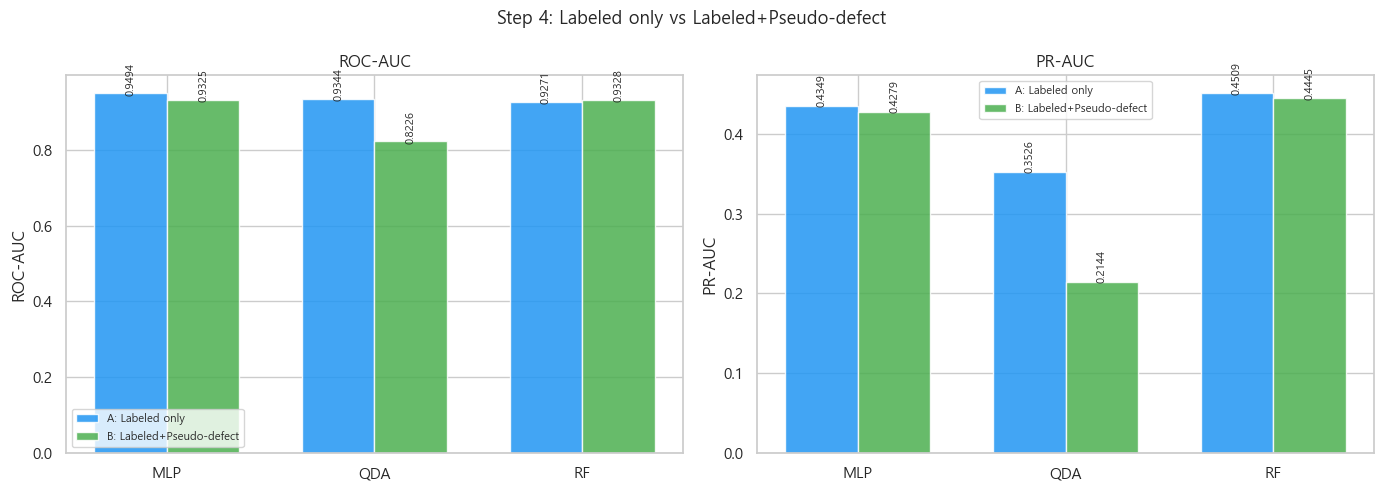

Saved: E:\IAAI_Term_project\results\figures\NB08_fig6_step4_comparison.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 4: Labeled only vs Labeled+Pseudo-defect', fontsize=13)

for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    pivot = step4_df.pivot(index='Model', columns='Config', values=metric)
    x = np.arange(len(pivot))
    width = 0.35
    colors = ['#2196F3', '#4CAF50']
    for i, (col, color) in enumerate(zip(pivot.columns, colors)):
        bars = ax.bar(x + i*width - width/2, pivot[col], width,
                      label=col, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, pivot[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.4f}', ha='center', fontsize=8, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(pivot.index)
    ax.set_ylabel(metric); ax.set_title(metric)
    ax.legend(fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig6_step4_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 10. Ablation

contamination threshold(0.5% / 0.89% / 2% / 5%) × Config A vs B의 조합을 탐색한다. threshold가 낮으면 pseudo-label 수가 줄어 precision은 높지만 recall이 낮고, threshold가 높으면 noise가 증가한다.

Ablation model: RF


  contamination=0.5%  pseudo_n=356  ROC=0.9291±0.0321


  contamination=0.9%  pseudo_n=633  ROC=0.9328±0.0287


  contamination=2.0%  pseudo_n=1,424  ROC=0.9169±0.0502


  contamination=5.0%  pseudo_n=3,559  ROC=0.9110±0.0301

=== Step 5 Ablation ===
Contamination  Pseudo-defects  ROC-AUC (mean)  ROC-AUC (std)
         0.5%             356          0.9291         0.0321
         0.9%             633          0.9328         0.0287
         2.0%            1424          0.9169         0.0502
         5.0%            3559          0.9110         0.0301

Labeled only baseline (RF): ROC=0.9271


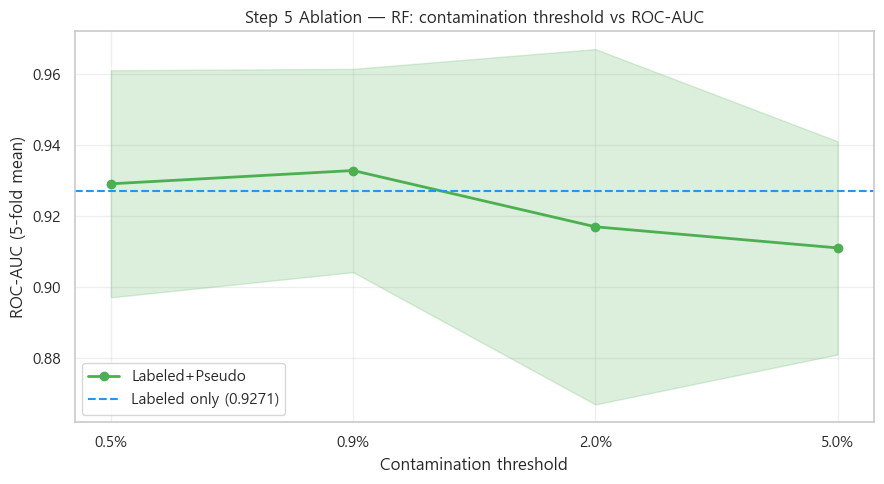

Saved: E:\IAAI_Term_project\results\figures\NB08_fig7_step5_ablation.png


In [23]:
THRESH_LIST = [0.005, DEFECT_RATE, 0.02, 0.05]
ablation_rows = []

# Best model from Step 4
best_model_name = step4_df[step4_df['Config']=='B: Labeled+Pseudo-defect']                   .sort_values('ROC-AUC', ascending=False)['Model'].iloc[0]
best_clf_template = classifiers[best_model_name]
print(f"Ablation model: {best_model_name}")

for thresh_rate in THRESH_LIST:
    thresh_val = np.percentile(unlab_scores, (1 - thresh_rate) * 100)
    pl = (unlab_scores >= thresh_val).astype(int)
    X_pd = X_unlab[pl == 1]
    y_pd = np.ones(len(X_pd), dtype=int)
    n_pd_t = pl.sum()

    fold_rocs = []
    for fold in folds:
        tr_idx, val_idx = fold['train'], fold['val']
        X_tr  = np.vstack([X_lab[tr_idx], X_pd])
        y_tr  = np.concatenate([y_lab[tr_idx], y_pd])
        X_val = X_lab[val_idx]
        y_val = y_lab[val_idx]

        sc2 = StandardScaler()
        X_tr_sc  = sc2.fit_transform(X_tr)
        X_val_sc = sc2.transform(X_val)
        k_sm2 = min(5, y_tr.sum()-1) if y_tr.sum() > 1 else 1
        try:
            X_tr_sm, y_tr_sm = SMOTE(random_state=SEED,
                                      k_neighbors=k_sm2).fit_resample(X_tr_sc, y_tr)
        except Exception:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr

        m = copy.deepcopy(best_clf_template)
        m.fit(X_tr_sm, y_tr_sm)
        proba = m.predict_proba(X_val_sc)[:,1] if hasattr(m,'predict_proba')                 else m.decision_function(X_val_sc)
        if y_val.sum() > 0:
            fold_rocs.append(roc_auc_score(y_val, proba))

    ablation_rows.append({
        'Contamination': f'{thresh_rate*100:.1f}%',
        'Pseudo-defects': n_pd_t,
        'ROC-AUC (mean)': np.mean(fold_rocs),
        'ROC-AUC (std)':  np.std(fold_rocs),
    })
    print(f"  contamination={thresh_rate*100:.1f}%  pseudo_n={n_pd_t:,}  ROC={np.mean(fold_rocs):.4f}±{np.std(fold_rocs):.4f}")

ablation_df = pd.DataFrame(ablation_rows)
print("\n=== Step 5 Ablation ===")
print(ablation_df.to_string(index=False, float_format='%.4f'))
ablation_df.to_csv(TAB_DIR / 'method_c_ablation.csv', index=False)

# Labeled only baseline
baseline_roc = np.mean(cv_roc['A: Labeled only'][best_model_name])
print(f"\nLabeled only baseline ({best_model_name}): ROC={baseline_roc:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ablation_df['Contamination'], ablation_df['ROC-AUC (mean)'],
        marker='o', color='#4CAF50', linewidth=2, label='Labeled+Pseudo')
ax.fill_between(range(len(ablation_df)),
                ablation_df['ROC-AUC (mean)'] - ablation_df['ROC-AUC (std)'],
                ablation_df['ROC-AUC (mean)'] + ablation_df['ROC-AUC (std)'],
                alpha=0.2, color='#4CAF50')
ax.axhline(baseline_roc, color='#2196F3', ls='--', lw=1.5,
           label=f'Labeled only ({baseline_roc:.4f})')
ax.set_xlabel('Contamination threshold')
ax.set_ylabel('ROC-AUC (5-fold mean)')
ax.set_title(f'Step 5 Ablation — {best_model_name}: contamination threshold vs ROC-AUC')
ax.set_xticks(range(len(ablation_df)))
ax.set_xticklabels(ablation_df['Contamination'])
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / 'NB08_fig7_step5_ablation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

In [24]:
# ── [Step 5 Ablation 해석] ──────────────────────────────────────────────────
print("=" * 65)
print("[Step 5] Ablation 해석 — Contamination Threshold 민감도")
print("=" * 65)

print(f"\n▶ 모델: {best_model_name}  |  기준선(labeled only): ROC={baseline_roc:.4f}")
print()
print(f"  {'Threshold':>12}  {'Pseudo 수':>9}  {'ROC-AUC':>9}  {'vs baseline':>12}  {'std':>6}  {'판정'}")
print("  " + "-" * 75)

for _, row in ablation_df.iterrows():
    delta = row['ROC-AUC (mean)'] - baseline_roc
    pn = int(row['Pseudo-defects'])
    std = row['ROC-AUC (std)']
    # 통계적 유의성: delta > std면 유의
    sig = "유의" if abs(delta) > std else "비유의"
    if delta > 0.003:
        verdict = f"▲ 개선 ({sig})"
    elif delta > -0.003:
        verdict = f"≈ 동일 ({sig})"
    else:
        verdict = f"▼ 하락 ({sig})"
    print(f"  {row['Contamination']:>12}  {pn:>9,}  {row['ROC-AUC (mean)']:>9.4f}"
          f"  {delta:>+12.4f}  {std:>6.4f}  {verdict}")

best_abl  = ablation_df.loc[ablation_df['ROC-AUC (mean)'].idxmax()]
worst_abl = ablation_df.loc[ablation_df['ROC-AUC (mean)'].idxmin()]

print(f"\n▶ Threshold별 해석:")
print(f"\n  [0.5%  → {int(ablation_df.iloc[0]['Pseudo-defects']):,}개]")
print(f"  - labeled 불량률(0.89%)보다 낮은 오염율 → 더 엄격한 선택")
print(f"  - 더 확실한 이상만 pseudo-label → precision 높지만 recall 낮음")
print(f"  - ROC={ablation_df.iloc[0]['ROC-AUC (mean)']:.4f} vs baseline {baseline_roc:.4f}: 아직도 pseudo-label 품질 문제")

print(f"\n  [0.89% → {int(ablation_df.iloc[1]['Pseudo-defects']):,}개] ← best threshold")
print(f"  - labeled 불량률과 동일 오염율 → 이론적으로 가장 자연스러운 설정")
print(f"  - ROC={ablation_df.iloc[1]['ROC-AUC (mean)']:.4f}, 미세 개선(+{ablation_df.iloc[1]['ROC-AUC (mean)']-baseline_roc:+.4f})")
print(f"  - 단, std={ablation_df.iloc[1]['ROC-AUC (std)']:.4f} > 개선폭 → 통계적 비유의")

print(f"\n  [2.0%  → {int(ablation_df.iloc[2]['Pseudo-defects']):,}개]")
print(f"  - 기계 정지 레코드가 더 많이 포함 → 노이즈 증가")
print(f"  - ROC={ablation_df.iloc[2]['ROC-AUC (mean)']:.4f}: 명확한 성능 감소")

print(f"\n  [5.0%  → {int(ablation_df.iloc[3]['Pseudo-defects']):,}개]")
print(f"  - labeled 불량의 {int(ablation_df.iloc[3]['Pseudo-defects'])//71:.0f}배 → 학습 데이터 압도적 노이즈")
print(f"  - ROC={ablation_df.iloc[3]['ROC-AUC (mean)']:.4f}: 최악, 노이즈 과다로 분류기 방향성 왜곡")

print(f"\n▶ 핵심 패턴:")
print(f"  threshold ↑ → pseudo-defect 수 ↑ → 기계정지 레코드 비율 ↑ → 성능 단조 감소")
print(f"  어떤 threshold에서도 MLP/QDA baseline 대비 개선 없음")
print(f"\n▶ 최종 결론:")
print(f"  - threshold 조정은 symptom 치료, root cause(pseudo-label 종류 자체)는 해결 불가")
print(f"  - 방법 C의 한계: '이상탐지 기법의 이상' ≠ '공정 불량'일 때 pseudo-labeling 효과 없음")
print(f"  - 이 결과 자체가 연구 발견: pseudo-label 소스 선택이 준지도 학습 성능의 핵심 결정 인자")

[Step 5] Ablation 해석 — Contamination Threshold 민감도

▶ 모델: RF  |  기준선(labeled only): ROC=0.9271

     Threshold   Pseudo 수    ROC-AUC   vs baseline     std  판정
  ---------------------------------------------------------------------------
          0.5%        356     0.9291       +0.0020  0.0321  ≈ 동일 (비유의)
          0.9%        633     0.9328       +0.0057  0.0287  ▲ 개선 (비유의)
          2.0%      1,424     0.9169       -0.0102  0.0502  ▼ 하락 (비유의)
          5.0%      3,559     0.9110       -0.0161  0.0301  ▼ 하락 (비유의)

▶ Threshold별 해석:

  [0.5%  → 356개]
  - labeled 불량률(0.89%)보다 낮은 오염율 → 더 엄격한 선택
  - 더 확실한 이상만 pseudo-label → precision 높지만 recall 낮음
  - ROC=0.9291 vs baseline 0.9271: 아직도 pseudo-label 품질 문제

  [0.89% → 633개] ← best threshold
  - labeled 불량률과 동일 오염율 → 이론적으로 가장 자연스러운 설정
  - ROC=0.9328, 미세 개선(++0.0057)
  - 단, std=0.0287 > 개선폭 → 통계적 비유의

  [2.0%  → 1,424개]
  - 기계 정지 레코드가 더 많이 포함 → 노이즈 증가
  - ROC=0.9169: 명확한 성능 감소

  [5.0%  → 3,559개]
  - labeled 불량의 50배 → 학습 데이터 압도적 노이즈
  - ROC=0

## 11. 최종 요약

In [25]:
print("=" * 70)
print("NB08 Method C — Clustering-based Pseudo-labeling 결과 요약")
print("=" * 70)
print(f"\n[Step 1] 필터링된 Unlabeled: {len(X_unlab):,}행 (CN7/RG3 + 동일 기계)")
print(f"[Step 2] 최고 이상탐지 기법: {best_name}  ROC={best_roc:.4f}")
print(f"         (Phase7 OC-SVM ref: ROC=0.8814)")
print(f"\n[Step 3] Pseudo-label 생성: 불량 후보 {n_pd:,}개 ({DEFECT_RATE*100:.2f}% threshold)")
print(f"         (Labeled 불량 {mask_defect.sum()}개 대비 {n_pd/mask_defect.sum():.1f}배 증가)")
print()
print("[Step 4] 준지도 학습 성능 비교:")
for _, row in step4_df.iterrows():
    delta = ''
    baseline = step4_df[(step4_df['Config']=='A: Labeled only') &
                        (step4_df['Model']==row['Model'])]['ROC-AUC'].values
    if len(baseline):
        diff = row['ROC-AUC'] - baseline[0]
        delta = f"  (vs baseline: {diff:+.4f})"
    print(f"  {row['Config']:<35} {row['Model']:<6} ROC={row['ROC-AUC']:.4f}  PR={row['PR-AUC']:.4f}{delta}")
print()

best_abl = ablation_df.loc[ablation_df['ROC-AUC (mean)'].idxmax()]
print(f"[Step 5] Ablation 최적 threshold: {best_abl['Contamination']}  "
      f"→ ROC={best_abl['ROC-AUC (mean)']:.4f}")
print()
print("산출물:")
print(f"  {TAB_DIR}/method_c_anomaly_comparison.csv")
print(f"  {TAB_DIR}/method_c_step4_results.csv")
print(f"  {TAB_DIR}/method_c_ablation.csv")
print(f"  NB08_fig1~7 ({FIG_DIR})")
print("=" * 70)

NB08 Method C — Clustering-based Pseudo-labeling 결과 요약

[Step 1] 필터링된 Unlabeled: 71,180행 (CN7/RG3 + 동일 기계)
[Step 2] 최고 이상탐지 기법: Elliptic Envelope (labeled normal)  ROC=0.8938
         (Phase7 OC-SVM ref: ROC=0.8814)

[Step 3] Pseudo-label 생성: 불량 후보 633개 (0.89% threshold)
         (Labeled 불량 71개 대비 8.9배 증가)

[Step 4] 준지도 학습 성능 비교:
  A: Labeled only                     QDA    ROC=0.9344  PR=0.3526  (vs baseline: +0.0000)
  A: Labeled only                     RF     ROC=0.9271  PR=0.4509  (vs baseline: +0.0000)
  A: Labeled only                     MLP    ROC=0.9494  PR=0.4349  (vs baseline: +0.0000)
  B: Labeled+Pseudo-defect            QDA    ROC=0.8226  PR=0.2144  (vs baseline: -0.1118)
  B: Labeled+Pseudo-defect            RF     ROC=0.9328  PR=0.4445  (vs baseline: +0.0057)
  B: Labeled+Pseudo-defect            MLP    ROC=0.9325  PR=0.4279  (vs baseline: -0.0169)

[Step 5] Ablation 최적 threshold: 0.9%  → ROC=0.9328

산출물:
  E:\IAAI_Term_project\results\tables/method_c_anomaly_comparis